# EviSpan-PR: Tuned Consistency-aware Multi-task Transformer + CRF

Notebook siap jalan untuk eksperimen **EviSpan-PR + CRF** dengan tuning khusus agar model consistency-aware lebih kompetitif terhadap baseline **Multi-task CRF no consistency**.

Perbaikan utama:

1. **Consistency loss sangat ringan** (`lambda = 0.005` secara default).
2. **Consistency warm-up**: consistency loss tidak langsung aktif sejak epoch awal.
3. **Positive-only consistency**: alignment difokuskan pada label dokumen yang benar-benar positif.
4. **One-way detach**: default `positive_only_detach_evidence`, sehingga span evidence menjadi teacher untuk document head tanpa menarik span head secara berlebihan.
5. **Noisy-or evidence pooling** untuk mengagregasi bukti span dari token-level BILUO emissions.
6. **Loss rebalance**: `cls_loss_weight = 1.2`, `ner_loss_weight = 1.0`, karena CRF sudah memperkuat span extraction.
7. **CRF layer pada NER/span head** dengan constrained BILUO decoding.
8. **Multi-label stratified CV**, visualisasi training/validation loss, confusion matrix, dan paper-ready reporting.

Target label final:

```text
Problem, Suggestion, Neutral, Appreciation
```

Jika dataset Anda sudah memakai empat label ini, biarkan `allow_legacy_label_aliases=False`. Jika masih memakai label lama seperti `SP`, `SA`, atau `Specific Problem`, ubah menjadi `True`.

In [1]:
# ============================================================
# 0. Install dependencies jika diperlukan
# ============================================================

# Jalankan sekali jika environment belum memiliki dependency berikut.
# Di Jupyter/Colab, hapus tanda komentar pada baris di bawah ini jika perlu.
# %pip install -q torch transformers scikit-learn seqeval pandas numpy tqdm matplotlib iterative-stratification pytorch-crf

In [2]:
# ============================================================
# 1. Imports
# ============================================================

import os
import gc
import json
import copy
import math
import random
import warnings
import subprocess
import sys
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Tuple
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    accuracy_score,
    classification_report,
    multilabel_confusion_matrix,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)

try:
    from iterstrat.ml_stratifiers import (
        MultilabelStratifiedKFold,
        MultilabelStratifiedShuffleSplit,
    )
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "iterative-stratification",
    ])
    from iterstrat.ml_stratifiers import (
        MultilabelStratifiedKFold,
        MultilabelStratifiedShuffleSplit,
    )

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)

try:
    from seqeval.metrics import (
        classification_report as seqeval_classification_report,
        f1_score as seqeval_f1_score,
        precision_score as seqeval_precision_score,
        recall_score as seqeval_recall_score,
    )
except ImportError as e:
    raise ImportError("seqeval belum tersedia. Jalankan: %pip install -q seqeval") from e

try:
    from torchcrf import CRF
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pytorch-crf",
    ])
    from torchcrf import CRF

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# 2. Configuration
# ============================================================

@dataclass
class Config:
    # Path dataset JSONL.
    # Sesuaikan path ini dengan lokasi file Anda.
    data_path: str = "/home/jupyter-sigitpurnomo/research/peer-review/dataset/peer-review-masdig-final.jsonl"

    # Model encoder.
    # Alternatif: "xlm-roberta-base" untuk mixed Indonesian-English.
    model_name: str = "indobenchmark/indobert-base-p1"

    output_dir: str = "/home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final"

    # Reproducibility
    seed: int = 42

    # Label normalization
    # False = hanya menerima Problem/Suggestion/Neutral/Appreciation.
    # True  = memetakan label lama seperti SP, SA, Specific Problem ke empat label final.
    allow_legacy_label_aliases: bool = False

    # Data split untuk single-split experiment
    test_size: float = 0.20
    val_size_from_train: float = 0.20

    # Tokenization
    max_length: int = 256

    # Training
    batch_size: int = 4
    num_epochs: int = 8
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    warmup_ratio: float = 0.10
    max_grad_norm: float = 1.0
    early_stopping_patience: int = 2

    # Multi-task loss weights for main EviSpan-PR
    # Span-optimized defaults:
    # - NER loss is up-weighted to improve span boundary learning.
    # - Consistency loss is kept mild to avoid overpowering span extraction.
    # Tuned defaults for CRF-based EviSpan-PR:
    # - CRF already strengthens span extraction, so NER loss is no longer up-weighted.
    # - Classification is slightly up-weighted to recover document-level Macro-F1.
    # - Consistency is very small and used as a soft regularizer.
    cls_loss_weight: float = 1.2
    ner_loss_weight: float = 1.0
    consistency_loss_weight: float = 0.005

    # Span extraction optimization
    use_ner_class_weights: bool = True
    ner_class_weight_max: float = 10.0
    ner_o_class_weight: float = 0.25

    # CRF layer for span extraction head.
    # CRF is used only for NER/span extraction, not document-level multi-label classification.
    use_crf: bool = True
    crf_enforce_biluo_constraints: bool = True

    # Auxiliary weighted token CE loss is kept to preserve class-weighted token learning.
    # The primary NER objective becomes CRF negative log-likelihood.
    auxiliary_token_ce_loss_weight: float = 0.20

    # Consistency-aware tuning
    # Options for consistency_type:
    # - "mse": standard MSE over all labels
    # - "positive_only": align only gold-positive document labels
    # - "positive_only_detach_evidence": span evidence guides document head, but span head is not pulled by consistency
    # - "positive_only_detach_doc": document head guides span evidence, but document head is not pulled by consistency
    # - "confidence_gated": apply consistency only to gold-positive or confident predictions
    consistency_type: str = "positive_only_detach_evidence"
    consistency_warmup_epochs: int = 2
    consistency_ramp_epochs: int = 2
    consistency_confidence_threshold: float = 0.60

    # Evidence pooling from token-level BILUO emissions to document-level evidence.
    # "noisy_or" is usually smoother than max pooling for evidence aggregation.
    # Options: "max", "noisy_or", "logsumexp".
    evidence_pooling: str = "noisy_or"
    logsumexp_temperature: float = 0.10

    # Optional extra post-processing after CRF/argmax decoding.
    use_biluo_constraint: bool = True

    # Document labels
    derive_doc_labels_from_spans_if_missing: bool = True

    # Evaluation
    threshold_default: float = 0.50
    threshold_grid_start: float = 0.10
    threshold_grid_end: float = 0.90
    threshold_grid_step: float = 0.05

    # Run modes
    run_single_split: bool = False
    run_multilabel_cv: bool = True
    run_ablation_cv: bool = True

    # Cross-validation
    cv_n_splits: int = 5
    inner_val_size: float = 0.20

    # Model variants to run in CV when run_ablation_cv=True
    selected_models_for_cv: Tuple[str, ...] = (
        "Document-only",
        "NER-only",
        "Multi-task no consistency",
        "EviSpan-PR",
        # Optional tuning variants below can be enabled if needed:
        # "EviSpan-PR lambda=0.01",
        # "EviSpan-PR positive-only",
        # "EviSpan-PR confidence-gated",
    )

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Config:")
print(json.dumps(asdict(CFG), indent=2, ensure_ascii=False))
print("Device:", device)

Config:
{
  "data_path": "/home/jupyter-sigitpurnomo/research/peer-review/dataset/peer-review-masdig-final.jsonl",
  "model_name": "indobenchmark/indobert-base-p1",
  "output_dir": "/home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final",
  "seed": 42,
  "allow_legacy_label_aliases": false,
  "test_size": 0.2,
  "val_size_from_train": 0.2,
  "max_length": 256,
  "batch_size": 4,
  "num_epochs": 8,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "max_grad_norm": 1.0,
  "early_stopping_patience": 2,
  "cls_loss_weight": 1.2,
  "ner_loss_weight": 1.0,
  "consistency_loss_weight": 0.005,
  "use_ner_class_weights": true,
  "ner_class_weight_max": 10.0,
  "ner_o_class_weight": 0.25,
  "use_crf": true,
  "crf_enforce_biluo_constraints": true,
  "auxiliary_token_ce_loss_weight": 0.2,
  "consistency_type": "positive_only_detach_evidence",
  "consistency_warmup_epochs": 2,
  "consistency_ramp_epochs": 2,
  "consistency_confidence_thre

In [4]:
# ============================================================
# 3. Label setup: 4 labels only + BILUO tags
# ============================================================

LABELS = ["Problem", "Suggestion", "Neutral", "Appreciation"]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}

VALID_LABEL_MAP = {
    "PROBLEM": "Problem",
    "SUGGESTION": "Suggestion",
    "NEUTRAL": "Neutral",
    "APPRECIATION": "Appreciation",
}

# Mapping ini tidak mengubah target label menjadi General/Specific.
# Semua tetap dipetakan ke empat label final.
LEGACY_LABEL_MAP = {
    # Problem
    "P": "Problem",
    "SP": "Problem",
    "GP": "Problem",
    "SPECIFIC PROBLEM": "Problem",
    "GENERAL PROBLEM": "Problem",

    # Suggestion
    "S": "Suggestion",
    "SS": "Suggestion",
    "GS": "Suggestion",
    "SPECIFIC SUGGESTION": "Suggestion",
    "GENERAL SUGGESTION": "Suggestion",

    # Neutral
    "N": "Neutral",
    "SN": "Neutral",
    "GN": "Neutral",
    "SPECIFIC NEUTRAL": "Neutral",
    "GENERAL NEUTRAL": "Neutral",

    # Appreciation
    "A": "Appreciation",
    "SA": "Appreciation",
    "GA": "Appreciation",
    "SPECIFIC APPRECIATION": "Appreciation",
    "GENERAL APPRECIATION": "Appreciation",
}

EXCLUDED_LABELS = {
    "PERSONAL COMMENT",
    "PERSONAL COMMENTS",
    "OUT OF TOPIC",
    "OFF TOPIC",
    "O",
}


def clean_label_key(raw_label: Any) -> str:
    x = str(raw_label).strip().upper().replace("_", " ").replace("-", " ")
    return " ".join(x.split())


def normalize_label(raw_label: Any, allow_legacy: Optional[bool] = None) -> Optional[str]:
    """
    Normalize raw label into one of four labels:
    Problem, Suggestion, Neutral, Appreciation.

    Returns None if label is excluded or invalid.
    """
    if allow_legacy is None:
        allow_legacy = CFG.allow_legacy_label_aliases

    if raw_label is None:
        return None

    key = clean_label_key(raw_label)
    if not key or key in EXCLUDED_LABELS:
        return None

    if key in VALID_LABEL_MAP:
        return VALID_LABEL_MAP[key]

    if allow_legacy and key in LEGACY_LABEL_MAP:
        return LEGACY_LABEL_MAP[key]

    return None


def normalize_label_list(raw_labels: Any, allow_legacy: Optional[bool] = None) -> List[str]:
    if raw_labels is None:
        return []
    if isinstance(raw_labels, str):
        raw_labels = [raw_labels]

    labels = []
    for raw in raw_labels:
        norm = normalize_label(raw, allow_legacy=allow_legacy)
        if norm in LABEL2ID:
            labels.append(norm)

    return sorted(set(labels), key=lambda x: LABEL2ID[x])


NER_TAGS = ["O"]
for label in LABELS:
    NER_TAGS.extend([
        f"B-{label}",
        f"I-{label}",
        f"L-{label}",
        f"U-{label}",
    ])

TAG2ID = {tag: i for i, tag in enumerate(NER_TAGS)}
ID2TAG = {i: tag for tag, i in TAG2ID.items()}

print("Classification labels:", LABELS)
print("NER tags:", NER_TAGS)

Classification labels: ['Problem', 'Suggestion', 'Neutral', 'Appreciation']
NER tags: ['O', 'B-Problem', 'I-Problem', 'L-Problem', 'U-Problem', 'B-Suggestion', 'I-Suggestion', 'L-Suggestion', 'U-Suggestion', 'B-Neutral', 'I-Neutral', 'L-Neutral', 'U-Neutral', 'B-Appreciation', 'I-Appreciation', 'L-Appreciation', 'U-Appreciation']


In [5]:
# ============================================================
# 4. Data loading
# ============================================================

def read_jsonl(path: str) -> List[Dict[str, Any]]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(f"Invalid JSONL at line {line_no}: {e}")
    return rows


def get_raw_doc_labels(obj: Dict[str, Any]) -> List[Any]:
    """
    Try common keys for document-level multi-label annotation.
    """
    for key in ["doc_labels", "labels", "accept", "label", "classification_labels"]:
        if key in obj and obj[key] is not None:
            value = obj[key]
            if isinstance(value, list):
                return value
            return [value]
    return []


def get_text_from_obj(obj: Dict[str, Any]) -> str:
    for key in ["text", "comment", "content", "review", "sentence"]:
        if key in obj and obj[key] is not None:
            return str(obj[key])
    raise KeyError("No text field found. Expected one of: text, comment, content, review, sentence")


def get_spans_from_obj(obj: Dict[str, Any], text: str) -> List[Dict[str, Any]]:
    raw_spans = obj.get("spans", []) or obj.get("entities", []) or []
    spans = []

    for s in raw_spans:
        if not isinstance(s, dict):
            continue

        label_raw = s.get("label", s.get("type", s.get("tag")))
        label = normalize_label(label_raw)
        if label not in LABEL2ID:
            continue

        if "start" in s and "end" in s:
            start = int(s["start"])
            end = int(s["end"])
        elif "start_char" in s and "end_char" in s:
            start = int(s["start_char"])
            end = int(s["end_char"])
        else:
            continue

        start = max(0, min(start, len(text)))
        end = max(0, min(end, len(text)))
        if start >= end:
            continue

        spans.append({
            "start": start,
            "end": end,
            "label": label,
            "text": text[start:end],
        })

    return sorted(spans, key=lambda x: (x["start"], x["end"], x["label"]))


def load_peer_review_dataframe(path: str) -> pd.DataFrame:
    raw_rows = read_jsonl(path)
    rows = []

    for idx, obj in enumerate(raw_rows):
        text = get_text_from_obj(obj)
        spans = get_spans_from_obj(obj, text)

        doc_labels = normalize_label_list(get_raw_doc_labels(obj))

        if not doc_labels and CFG.derive_doc_labels_from_spans_if_missing:
            doc_labels = sorted({s["label"] for s in spans}, key=lambda x: LABEL2ID[x])

        # Exclude examples with no valid document label and no valid span.
        if not doc_labels and not spans:
            continue

        rows.append({
            "id": obj.get("id", idx),
            "text": text,
            "doc_labels": doc_labels,
            "spans": spans,
            "n_chars": len(text),
            "n_spans": len(spans),
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(
            "No valid examples loaded. Check label names or set CFG.allow_legacy_label_aliases=True if using old labels."
        )

    return df


df = load_peer_review_dataframe(CFG.data_path)

print("Loaded examples:", len(df))
print("Document label counts:")
print(Counter(label for labels in df["doc_labels"] for label in labels))
print("Span label counts:")
print(Counter(s["label"] for spans in df["spans"] for s in spans))

display(df.head())

Loaded examples: 727
Document label counts:
Counter({'Appreciation': 632, 'Problem': 274, 'Neutral': 157, 'Suggestion': 131})
Span label counts:
Counter({'Appreciation': 1308, 'Problem': 491, 'Neutral': 236, 'Suggestion': 177})


,id,text,doc_labels,spans,n_chars,n_spans
0,0,"Menurut saya Baik. karena, di bagian objective...","[Neutral, Appreciation]","[{'start': 0, 'end': 108, 'label': 'Appreciati...",480,4
1,1,Penjelasan cukup baik tapi materi yang dipapar...,"[Problem, Appreciation]","[{'start': 0, 'end': 21, 'label': 'Appreciatio...",156,4
2,2,Penggunaan bahasa dan kalimat dapat dipahami. ...,"[Suggestion, Appreciation]","[{'start': 0, 'end': 45, 'label': 'Appreciatio...",157,3
3,3,Penilaian saya terhadap Kelompok 7 didasari ol...,"[Problem, Appreciation]","[{'start': 0, 'end': 559, 'label': 'Problem', ...",935,3
4,4,Bahasa dan tata cara penulisan yang digunakan ...,[Problem],"[{'start': 0, 'end': 105, 'label': 'Problem', ...",440,4


In [6]:
# ============================================================
# 5. Multi-hot labels and multi-label stratified split utilities
# ============================================================


def multi_hot(labels: List[str]) -> np.ndarray:
    y = np.zeros(len(LABELS), dtype=np.float32)
    for label in labels or []:
        if label in LABEL2ID:
            y[LABEL2ID[label]] = 1.0
    return y


def labels_to_multihot_matrix(dataframe: pd.DataFrame) -> np.ndarray:
    return np.stack([multi_hot(labels) for labels in dataframe["doc_labels"]]).astype(int)


def multilabel_train_test_split(
    dataframe: pd.DataFrame,
    test_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Multi-label stratified split using iterative stratification.
    """
    dataframe = dataframe.reset_index(drop=True)
    y = labels_to_multihot_matrix(dataframe)

    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=test_size,
        random_state=seed,
    )

    train_idx, test_idx = next(splitter.split(np.zeros(len(dataframe)), y))

    train_df = dataframe.iloc[train_idx].reset_index(drop=True)
    test_df = dataframe.iloc[test_idx].reset_index(drop=True)

    return train_df, test_df


def show_label_distribution(name: str, dataframe: pd.DataFrame):
    counts = Counter(label for labels in dataframe["doc_labels"] for label in labels)
    print(f"\n{name}: n={len(dataframe)}")
    for label in LABELS:
        print(f"  {label:12s}: {counts.get(label, 0)}")


train_val_df, test_df = multilabel_train_test_split(df, CFG.test_size, CFG.seed)
train_df, val_df = multilabel_train_test_split(train_val_df, CFG.val_size_from_train, CFG.seed + 1)

show_label_distribution("Train", train_df)
show_label_distribution("Validation", val_df)
show_label_distribution("Test", test_df)


Train: n=469
  Problem     : 175
  Suggestion  : 84
  Neutral     : 100
  Appreciation: 404

Validation: n=116
  Problem     : 44
  Suggestion  : 21
  Neutral     : 25
  Appreciation: 101

Test: n=142
  Problem     : 55
  Suggestion  : 26
  Neutral     : 32
  Appreciation: 127


In [7]:
# ============================================================
# 6. Tokenizer and BILUO alignment
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(CFG.model_name, use_fast=True)
if not tokenizer.is_fast:
    raise ValueError("This pipeline requires a fast tokenizer for offset_mapping.")


def char_overlap(a_start: int, a_end: int, b_start: int, b_end: int) -> bool:
    return max(a_start, b_start) < min(a_end, b_end)


def align_biluo_tags(
    text: str,
    spans: List[Dict[str, Any]],
    tokenizer,
    max_length: int,
) -> Dict[str, Any]:
    """
    Tokenize text and align span character offsets into BILUO tag ids.
    """
    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_offsets_mapping=True,
    )

    offsets = encoding["offset_mapping"]
    sequence_ids = encoding.sequence_ids() if hasattr(encoding, "sequence_ids") else [None] * len(offsets)

    tag_ids = [TAG2ID["O"]] * len(offsets)
    for i, (offset, seq_id) in enumerate(zip(offsets, sequence_ids)):
        if seq_id is None or tuple(offset) == (0, 0):
            tag_ids[i] = -100

    overlap_warnings = []

    for span in sorted(spans, key=lambda s: (s["start"], s["end"])):
        label = normalize_label(span.get("label"))
        if label not in LABEL2ID:
            continue

        ids = {
            "B": TAG2ID[f"B-{label}"],
            "I": TAG2ID[f"I-{label}"],
            "L": TAG2ID[f"L-{label}"],
            "U": TAG2ID[f"U-{label}"],
        }

        token_indices = []
        for tok_idx, (tok_start, tok_end) in enumerate(offsets):
            if tag_ids[tok_idx] == -100:
                continue
            if tok_start == tok_end:
                continue
            if char_overlap(tok_start, tok_end, span["start"], span["end"]):
                token_indices.append(tok_idx)

        if not token_indices:
            continue

        if len(token_indices) == 1:
            biluo_tags = [ids["U"]]
        else:
            biluo_tags = []
            for j, _ in enumerate(token_indices):
                if j == 0:
                    biluo_tags.append(ids["B"])
                elif j == len(token_indices) - 1:
                    biluo_tags.append(ids["L"])
                else:
                    biluo_tags.append(ids["I"])

        for tok_idx, new_tag in zip(token_indices, biluo_tags):
            old_tag = tag_ids[tok_idx]
            if old_tag != TAG2ID["O"] and old_tag != new_tag:
                overlap_warnings.append({
                    "token_idx": tok_idx,
                    "old_tag": ID2TAG.get(old_tag, old_tag),
                    "new_tag": ID2TAG[new_tag],
                    "span": span,
                })
                continue
            tag_ids[tok_idx] = new_tag

    encoding["labels_ner"] = tag_ids
    encoding["offset_mapping"] = [tuple(x) for x in offsets]
    encoding["overlap_warnings"] = overlap_warnings
    return encoding


def encode_dataframe(part_df: pd.DataFrame, tokenizer, cfg: Config) -> List[Dict[str, Any]]:
    features = []
    for _, row in part_df.iterrows():
        enc = align_biluo_tags(row["text"], row["spans"], tokenizer, cfg.max_length)
        item = {
            "id": row["id"],
            "text": row["text"],
            "doc_labels": row["doc_labels"],
            "spans": row["spans"],
            "labels_cls": multi_hot(row["doc_labels"]),
            "labels_ner": enc["labels_ner"],
            "offset_mapping": enc["offset_mapping"],
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "overlap_warnings": enc["overlap_warnings"],
        }
        if "token_type_ids" in enc:
            item["token_type_ids"] = enc["token_type_ids"]
        features.append(item)
    return features


train_features = encode_dataframe(train_df, tokenizer, CFG)
val_features = encode_dataframe(val_df, tokenizer, CFG)
test_features = encode_dataframe(test_df, tokenizer, CFG)

print("Encoded:", len(train_features), len(val_features), len(test_features))
print("BILUO overlap warnings:", sum(len(f["overlap_warnings"]) for f in train_features + val_features + test_features))

# Preview one example
ex = train_features[0]
preview = pd.DataFrame({
    "token": tokenizer.convert_ids_to_tokens(ex["input_ids"][:80]),
    "offset": ex["offset_mapping"][:80],
    "tag": [ID2TAG[t] if t != -100 else "IGN" for t in ex["labels_ner"][:80]],
})
display(preview)

Encoded: 469 116 142
BILUO overlap warnings: 0


,token,offset,tag
0,[CLS],"(0, 0)",IGN
1,menurut,"(0, 7)",B-Appreciation
2,saya,"(8, 12)",I-Appreciation
3,baik,"(13, 17)",I-Appreciation
4,.,"(17, 18)",I-Appreciation
...,...,...,...
75,media,"(428, 433)",I-Neutral
76,digital,"(434, 441)",I-Neutral
77,sehingga,"(442, 450)",I-Neutral
78,tidak,"(451, 456)",I-Neutral


In [8]:
# ============================================================
# 7. Dataset and DataLoader
# ============================================================

class FeatureDataset(Dataset):
    def __init__(self, features: List[Dict[str, Any]]):
        self.features = features

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        f = self.features[idx]
        item = {
            "example_idx": torch.tensor(idx, dtype=torch.long),
            "input_ids": torch.tensor(f["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(f["attention_mask"], dtype=torch.long),
            "labels_cls": torch.tensor(f["labels_cls"], dtype=torch.float),
            "labels_ner": torch.tensor(f["labels_ner"], dtype=torch.long),
        }
        if "token_type_ids" in f:
            item["token_type_ids"] = torch.tensor(f["token_type_ids"], dtype=torch.long)
        return item


def make_loader(features: List[Dict[str, Any]], batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        FeatureDataset(features),
        batch_size=batch_size,
        shuffle=shuffle,
    )


def batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    return {k: v.to(device) for k, v in batch.items() if k != "example_idx" and torch.is_tensor(v)}


train_loader = make_loader(train_features, CFG.batch_size, shuffle=True)
val_loader = make_loader(val_features, CFG.batch_size, shuffle=False)
test_loader = make_loader(test_features, CFG.batch_size, shuffle=False)

In [9]:
# ============================================================
# 8. Model: EviSpan-PR
# ============================================================

def compute_pos_weight(features: List[Dict[str, Any]], max_weight: float = 10.0) -> torch.Tensor:
    """
    Positive class weights for document-level multi-label classification.
    """
    y = np.stack([f["labels_cls"] for f in features])
    pos = y.sum(axis=0)
    neg = len(y) - pos

    weights = np.where(pos > 0, neg / np.maximum(pos, 1), 1.0)
    weights = np.clip(weights, 1.0, max_weight)

    return torch.tensor(weights, dtype=torch.float)


def compute_ner_class_weights(
    features: List[Dict[str, Any]],
    num_tags: int,
    max_weight: float = 10.0,
    o_weight: float = 0.25,
) -> torch.Tensor:
    """
    Compute class weights for token-level BILUO tagging.

    Motivation:
    - In span extraction, most tokens are usually "O".
    - Without class weighting, the model may become too conservative and over-predict "O".
    - This function up-weights rare B/I/L/U tags and down-weights "O".

    Notes:
    - Positions with -100 are ignored.
    - Tags that do not appear in the training fold get weight 1.0.
    - "O" is explicitly down-weighted using o_weight.
    """
    counts = np.zeros(num_tags, dtype=np.float64)

    for f in features:
        for tag_id in f["labels_ner"]:
            if int(tag_id) == -100:
                continue
            counts[int(tag_id)] += 1.0

    weights = np.ones(num_tags, dtype=np.float64)
    total = counts.sum()
    n_present = max((counts > 0).sum(), 1)

    present = counts > 0
    weights[present] = total / (n_present * np.maximum(counts[present], 1.0))

    # Only up-weight rare non-O tags; do not push common tags below 1,
    # except the O tag which is intentionally down-weighted.
    weights = np.clip(weights, 1.0, max_weight)

    if "O" in TAG2ID:
        weights[TAG2ID["O"]] = float(o_weight)

    return torch.tensor(weights, dtype=torch.float)


def describe_ner_class_weights(weights: torch.Tensor) -> pd.DataFrame:
    """
    Human-readable table of BILUO class weights.
    """
    return pd.DataFrame({
        "tag": [ID2TAG[i] for i in range(len(ID2TAG))],
        "weight": weights.detach().cpu().numpy(),
    })



# ============================================================
# CRF transition constraints for BILUO
# ============================================================

def split_tag(tag: str) -> Tuple[str, Optional[str]]:
    if tag == "O" or "-" not in tag:
        return tag, None
    prefix, label = tag.split("-", 1)
    return prefix, label


def build_biluo_transition_masks(
    tag2id: Dict[str, int],
    id2tag: Dict[int, str],
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Build masks for legal BILUO transitions.

    Returns:
        allowed_start: [num_tags]
        allowed_end: [num_tags]
        allowed_transitions: [num_tags, num_tags]

    Transition direction follows torchcrf:
        transitions[from_tag, to_tag]
    """
    num_tags = len(tag2id)
    allowed_start = torch.zeros(num_tags, dtype=torch.bool)
    allowed_end = torch.zeros(num_tags, dtype=torch.bool)
    allowed_transitions = torch.zeros(num_tags, num_tags, dtype=torch.bool)

    for i in range(num_tags):
        prefix_i, label_i = split_tag(id2tag[i])

        # A sequence may start with O, B-X, or U-X.
        if prefix_i in {"O", "B", "U"}:
            allowed_start[i] = True

        # A sequence may end with O, L-X, or U-X.
        if prefix_i in {"O", "L", "U"}:
            allowed_end[i] = True

    for i in range(num_tags):
        prefix_i, label_i = split_tag(id2tag[i])

        for j in range(num_tags):
            prefix_j, label_j = split_tag(id2tag[j])

            allowed = False

            # Outside or closed span can be followed by outside or a new span.
            if prefix_i in {"O", "L", "U"}:
                allowed = prefix_j in {"O", "B", "U"}

            # B-X must be followed by I-X or L-X.
            elif prefix_i == "B":
                allowed = (
                    label_i == label_j
                    and prefix_j in {"I", "L"}
                )

            # I-X must be followed by I-X or L-X.
            elif prefix_i == "I":
                allowed = (
                    label_i == label_j
                    and prefix_j in {"I", "L"}
                )

            if allowed:
                allowed_transitions[i, j] = True

    return allowed_start, allowed_end, allowed_transitions


class EviSpanPR(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels_cls: int,
        num_ner_tags: int,
        cls_pos_weight: Optional[torch.Tensor] = None,
        ner_class_weights: Optional[torch.Tensor] = None,
        dropout_prob: float = 0.10,
        use_crf: bool = True,
        crf_enforce_biluo_constraints: bool = True,
        auxiliary_token_ce_loss_weight: float = 0.20,
        evidence_pooling: str = "noisy_or",
        logsumexp_temperature: float = 0.10,
        consistency_type: str = "positive_only_detach_evidence",
        consistency_confidence_threshold: float = 0.60,
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout_prob)

        # Document-level multi-label classification head.
        # This remains Linear -> Sigmoid + BCEWithLogitsLoss.
        self.cls_head = nn.Linear(hidden_size, num_labels_cls)

        # Token-level BILUO emission head.
        # If use_crf=True, these emissions are passed to a CRF layer.
        self.ner_head = nn.Linear(hidden_size, num_ner_tags)

        self.use_crf = bool(use_crf)
        self.crf_enforce_biluo_constraints = bool(crf_enforce_biluo_constraints)
        self.auxiliary_token_ce_loss_weight = float(auxiliary_token_ce_loss_weight)
        self.evidence_pooling = str(evidence_pooling)
        self.logsumexp_temperature = float(logsumexp_temperature)
        self.consistency_type = str(consistency_type)
        self.consistency_confidence_threshold = float(consistency_confidence_threshold)

        if self.use_crf:
            self.crf = CRF(
                num_tags=num_ner_tags,
                batch_first=True,
            )

            allowed_start, allowed_end, allowed_transitions = build_biluo_transition_masks(
                TAG2ID,
                ID2TAG,
            )

            self.register_buffer("crf_allowed_start", allowed_start)
            self.register_buffer("crf_allowed_end", allowed_end)
            self.register_buffer("crf_allowed_transitions", allowed_transitions)

            if self.crf_enforce_biluo_constraints:
                self.apply_crf_constraints()

        if cls_pos_weight is None:
            cls_pos_weight = torch.ones(num_labels_cls, dtype=torch.float)

        if ner_class_weights is None:
            ner_class_weights = torch.ones(num_ner_tags, dtype=torch.float)

        self.register_buffer("cls_pos_weight", cls_pos_weight.float())
        self.register_buffer("ner_class_weights", ner_class_weights.float())

    @torch.no_grad()
    def apply_crf_constraints(self):
        """
        Keep invalid BILUO transitions very unlikely in the CRF.

        This method is called:
        - after CRF initialization,
        - after optimizer updates during training.

        The values are not set to -inf to avoid numerical issues.
        """
        if not self.use_crf:
            return

        neg = -10000.0

        self.crf.start_transitions.data.masked_fill_(
            ~self.crf_allowed_start.to(self.crf.start_transitions.device),
            neg,
        )

        self.crf.end_transitions.data.masked_fill_(
            ~self.crf_allowed_end.to(self.crf.end_transitions.device),
            neg,
        )

        self.crf.transitions.data.masked_fill_(
            ~self.crf_allowed_transitions.to(self.crf.transitions.device),
            neg,
        )

    def aggregate_span_evidence(
        self,
        ner_logits: torch.Tensor,
        token_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Convert token-level BILUO emission probabilities into document-level
        evidence probabilities.

        Even when CRF is used, emission logits provide a differentiable proxy
        for span evidence. This tuned version supports several pooling methods:
        - max: evidence is the strongest token signal
        - noisy_or: evidence accumulates over multiple supporting tokens
        - logsumexp: smooth approximation of max pooling
        """
        probs = torch.softmax(ner_logits, dim=-1)
        class_evidences = []

        for label in LABELS:
            tag_ids = [
                TAG2ID[f"B-{label}"],
                TAG2ID[f"I-{label}"],
                TAG2ID[f"L-{label}"],
                TAG2ID[f"U-{label}"],
            ]

            label_token_prob = sum(probs[:, :, tid] for tid in tag_ids)
            label_token_prob = label_token_prob.masked_fill(~token_mask, 0.0)

            if self.evidence_pooling == "max":
                evidence = torch.amax(label_token_prob, dim=1)

            elif self.evidence_pooling == "noisy_or":
                # Smooth multi-token evidence aggregation:
                # if several tokens moderately support the label, evidence increases.
                p = torch.clamp(label_token_prob, 1e-6, 1.0 - 1e-6)
                p = p.masked_fill(~token_mask, 0.0)
                evidence = 1.0 - torch.prod(1.0 - p, dim=1)

            elif self.evidence_pooling == "logsumexp":
                temperature = max(float(self.logsumexp_temperature), 1e-6)
                x = label_token_prob.masked_fill(~token_mask, -1e4)
                evidence = temperature * torch.logsumexp(x / temperature, dim=1)
                evidence = torch.clamp(evidence, 0.0, 1.0)

            else:
                raise ValueError(f"Unknown evidence_pooling: {self.evidence_pooling}")

            class_evidences.append(evidence)

        return torch.stack(class_evidences, dim=1)

    def compute_consistency_loss(
        self,
        doc_probs: torch.Tensor,
        evidence_probs: torch.Tensor,
        labels_cls: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        """
        Tunable document-span consistency loss.

        The default is positive_only_detach_evidence:
        - only gold-positive labels are aligned;
        - span evidence acts as a teacher for the document head;
        - the span/CRF branch is not pulled by the consistency penalty.

        This is designed to avoid negative transfer from an overly strong
        consistency objective in the CRF setting.
        """
        ctype = self.consistency_type
        eps = 1e-8

        if ctype == "mse":
            return torch.mean((doc_probs - evidence_probs) ** 2)

        if labels_cls is None:
            return torch.mean((doc_probs - evidence_probs) ** 2)

        pos_mask = labels_cls.float()

        if ctype == "positive_only":
            loss = ((doc_probs - evidence_probs) ** 2) * pos_mask
            return loss.sum() / (pos_mask.sum() + eps)

        if ctype == "positive_only_detach_evidence":
            loss = ((doc_probs - evidence_probs.detach()) ** 2) * pos_mask
            return loss.sum() / (pos_mask.sum() + eps)

        if ctype == "positive_only_detach_doc":
            loss = ((doc_probs.detach() - evidence_probs) ** 2) * pos_mask
            return loss.sum() / (pos_mask.sum() + eps)

        if ctype == "confidence_gated":
            confidence_mask = (
                (labels_cls == 1)
                | (doc_probs.detach() >= self.consistency_confidence_threshold)
                | (evidence_probs.detach() >= self.consistency_confidence_threshold)
            ).float()
            loss = ((doc_probs - evidence_probs) ** 2) * confidence_mask
            return loss.sum() / (confidence_mask.sum() + eps)

        raise ValueError(f"Unknown consistency_type: {ctype}")

    def decode_ner(
        self,
        ner_logits: torch.Tensor,
        token_mask: torch.Tensor,
    ) -> List[List[int]]:
        """
        Decode token-level tags.

        If CRF is enabled, use Viterbi decoding.
        Otherwise, use argmax decoding.
        """
        if self.use_crf:
            return self.crf.decode(
                ner_logits,
                mask=token_mask.bool(),
            )

        pred_ids = torch.argmax(ner_logits, dim=-1)
        decoded = []

        for row_pred, row_mask in zip(pred_ids, token_mask):
            decoded.append(row_pred[row_mask.bool()].detach().cpu().tolist())

        return decoded

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels_cls: Optional[torch.Tensor] = None,
        labels_ner: Optional[torch.Tensor] = None,
        token_type_ids: Optional[torch.Tensor] = None,
        cls_loss_weight: float = 1.0,
        ner_loss_weight: float = 1.5,
        consistency_loss_weight: float = 0.05,
    ) -> Dict[str, torch.Tensor]:

        encoder_kwargs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
        }

        if (
            token_type_ids is not None
            and "token_type_ids" in self.encoder.forward.__code__.co_varnames
        ):
            encoder_kwargs["token_type_ids"] = token_type_ids

        outputs = self.encoder(**encoder_kwargs)

        sequence_output = outputs.last_hidden_state
        pooled_output = sequence_output[:, 0, :]

        cls_logits = self.cls_head(
            self.dropout(pooled_output)
        )

        # Emissions for BILUO tags.
        ner_logits = self.ner_head(
            self.dropout(sequence_output)
        )

        result = {
            "cls_logits": cls_logits,
            "ner_logits": ner_logits,
        }

        if labels_cls is not None and labels_ner is not None:
            # ============================================================
            # 1) Document-level multi-label classification loss
            # ============================================================

            cls_loss_fct = nn.BCEWithLogitsLoss(
                pos_weight=self.cls_pos_weight.to(cls_logits.device)
            )

            cls_loss = cls_loss_fct(
                cls_logits,
                labels_cls,
            )

            # ============================================================
            # 2) Span extraction loss
            # ============================================================

            # Mask for valid text tokens only. This is used for auxiliary CE
            # and evidence aggregation. It ignores special tokens and padding.
            token_mask = labels_ner.ne(-100) & attention_mask.bool()

            # Mask for CRF. pytorch-crf requires the first timestep in each
            # sequence to be valid, so we use attention_mask and set special
            # token labels to O.
            crf_mask = attention_mask.bool()

            safe_labels_ner = labels_ner.masked_fill(
                labels_ner.eq(-100),
                TAG2ID["O"],
            )

            weighted_ce_fct = nn.CrossEntropyLoss(
                weight=self.ner_class_weights.to(ner_logits.device),
                ignore_index=-100,
            )

            auxiliary_token_ce_loss = weighted_ce_fct(
                ner_logits.view(-1, ner_logits.size(-1)),
                labels_ner.view(-1),
            )

            if self.use_crf:
                # CRF negative log-likelihood.
                # torchcrf returns log likelihood, so we negate it.
                crf_log_likelihood = self.crf(
                    ner_logits,
                    safe_labels_ner,
                    mask=crf_mask.bool(),
                    reduction="mean",
                )

                crf_loss = -crf_log_likelihood

                # The auxiliary weighted CE loss preserves class-weighted
                # token-level learning, especially for rare B/I/L/U tags.
                ner_loss = (
                    crf_loss
                    + self.auxiliary_token_ce_loss_weight * auxiliary_token_ce_loss
                )
            else:
                crf_loss = torch.tensor(
                    0.0,
                    device=ner_logits.device,
                )
                ner_loss = auxiliary_token_ce_loss

            # ============================================================
            # 3) Mild document-span consistency loss
            # ============================================================

            doc_probs = torch.sigmoid(cls_logits)

            evidence_probs = self.aggregate_span_evidence(
                ner_logits=ner_logits,
                token_mask=token_mask,
            )

            consistency_loss = self.compute_consistency_loss(
                doc_probs=doc_probs,
                evidence_probs=evidence_probs,
                labels_cls=labels_cls,
            )

            total_loss = (
                cls_loss_weight * cls_loss
                + ner_loss_weight * ner_loss
                + consistency_loss_weight * consistency_loss
            )

            result.update({
                "loss": total_loss,
                "cls_loss": cls_loss.detach(),
                "ner_loss": ner_loss.detach(),
                "crf_loss": crf_loss.detach(),
                "auxiliary_token_ce_loss": auxiliary_token_ce_loss.detach(),
                "consistency_loss": consistency_loss.detach(),
                "evidence_probs": evidence_probs.detach(),
            })

        return result


# ============================================================
# Model variants
# ============================================================

MODEL_VARIANTS = {
    "Document-only": {
        "cls_loss_weight": 1.0,
        "ner_loss_weight": 0.0,
        "consistency_loss_weight": 0.0,
        "report_classification": True,
        "report_span": False,
        "report_consistency": False,
    },

    "NER-only": {
        "cls_loss_weight": 0.0,
        "ner_loss_weight": 1.0,
        "consistency_loss_weight": 0.0,
        "report_classification": False,
        "report_span": True,
        "report_consistency": False,
    },

    # Strong CRF baseline to beat.
    "Multi-task no consistency": {
        "cls_loss_weight": 1.0,
        "ner_loss_weight": 1.5,
        "consistency_loss_weight": 0.0,
        "report_classification": True,
        "report_span": True,
        "report_consistency": True,
    },

    # Tuned consistency-aware EviSpan-PR.
    # Goal: recover classification performance while keeping CRF-level Span F1.
    "EviSpan-PR": {
        "cls_loss_weight": CFG.cls_loss_weight,
        "ner_loss_weight": CFG.ner_loss_weight,
        "consistency_loss_weight": CFG.consistency_loss_weight,
        "report_classification": True,
        "report_span": True,
        "report_consistency": True,
        "consistency_type": CFG.consistency_type,
    },

    # Optional tuning variants for quick ablation.
    "EviSpan-PR lambda=0.01": {
        "cls_loss_weight": 1.2,
        "ner_loss_weight": 1.0,
        "consistency_loss_weight": 0.01,
        "report_classification": True,
        "report_span": True,
        "report_consistency": True,
        "consistency_type": "positive_only_detach_evidence",
    },

    "EviSpan-PR positive-only": {
        "cls_loss_weight": 1.2,
        "ner_loss_weight": 1.0,
        "consistency_loss_weight": 0.005,
        "report_classification": True,
        "report_span": True,
        "report_consistency": True,
        "consistency_type": "positive_only",
    },

    "EviSpan-PR confidence-gated": {
        "cls_loss_weight": 1.2,
        "ner_loss_weight": 1.0,
        "consistency_loss_weight": 0.005,
        "report_classification": True,
        "report_span": True,
        "report_consistency": True,
        "consistency_type": "confidence_gated",
    },
}

cls_pos_weight = compute_pos_weight(train_features)
print("Classification pos_weight:", dict(zip(LABELS, cls_pos_weight.tolist())))

if CFG.use_ner_class_weights:
    ner_class_weights_preview = compute_ner_class_weights(
        features=train_features,
        num_tags=len(NER_TAGS),
        max_weight=CFG.ner_class_weight_max,
        o_weight=CFG.ner_o_class_weight,
    )
else:
    ner_class_weights_preview = torch.ones(len(NER_TAGS), dtype=torch.float)

print("NER class weights preview:")
display(describe_ner_class_weights(ner_class_weights_preview))

Classification pos_weight: {'Problem': 1.6799999475479126, 'Suggestion': 4.583333492279053, 'Neutral': 3.690000057220459, 'Appreciation': 1.0}
NER class weights preview:


,tag,weight
0,O,0.250000
1,B-Problem,5.152125
2,I-Problem,1.000000
3,L-Problem,5.152125
4,U-Problem,1.000000
5,B-Suggestion,10.000000
6,I-Suggestion,1.000000
7,L-Suggestion,10.000000
8,U-Suggestion,1.000000
9,B-Neutral,10.000000


In [10]:
# ============================================================
# 9. BILUO decoding and seqeval compatibility
# ============================================================

def ids_to_biluo_tags(tag_ids: List[int], true_tag_ids: Optional[List[int]] = None) -> List[str]:
    tags = []
    for i, tag_id in enumerate(tag_ids):
        if true_tag_ids is not None and true_tag_ids[i] == -100:
            continue
        if int(tag_id) == -100:
            continue
        tags.append(ID2TAG[int(tag_id)])
    return tags


def biluo_to_iobes_tags(tags: List[str]) -> List[str]:
    converted = []
    for tag in tags:
        if tag == "O":
            converted.append("O")
            continue
        if "-" not in tag:
            converted.append("O")
            continue
        prefix, label = tag.split("-", 1)
        if prefix == "B":
            converted.append(f"B-{label}")
        elif prefix == "I":
            converted.append(f"I-{label}")
        elif prefix == "L":
            converted.append(f"E-{label}")
        elif prefix == "U":
            converted.append(f"S-{label}")
        else:
            converted.append("O")
    return converted



def biluo_tags_to_ids(tags: List[str]) -> List[int]:
    """
    Convert BILUO tag strings to tag ids.
    Unknown or invalid tags are mapped to O.
    """
    return [
        TAG2ID.get(tag, TAG2ID["O"])
        for tag in tags
    ]


def repair_biluo_sequence(tags: List[str]) -> List[str]:
    """
    Constrained BILUO decoding post-processing.

    The raw argmax sequence may contain invalid transitions, e.g.:
    - I-Problem without a preceding B-Problem
    - L-Suggestion without an active Suggestion span
    - B-Problem followed immediately by O

    This function greedily converts the sequence into a valid BILUO-style
    sequence while preserving labels as much as possible.

    Examples:
    - B-X O        -> U-X O
    - B-X I-X O    -> B-X L-X O
    - I-X L-X      -> B-X L-X
    - L-X without B -> U-X
    """
    repaired = []
    n = len(tags)
    i = 0

    while i < n:
        tag = tags[i]

        if tag == "O" or "-" not in tag:
            repaired.append("O")
            i += 1
            continue

        prefix, label = tag.split("-", 1)

        if label not in LABEL2ID:
            repaired.append("O")
            i += 1
            continue

        # A unit tag is already a complete span.
        if prefix == "U":
            repaired.append(f"U-{label}")
            i += 1
            continue

        # L without a preceding B/I becomes a unit span.
        if prefix == "L":
            repaired.append(f"U-{label}")
            i += 1
            continue

        # B or invalid I can start a span.
        if prefix in {"B", "I"}:
            start = i
            j = i + 1

            # Consume consecutive I-label tokens.
            while j < n:
                next_tag = tags[j]

                if "-" not in next_tag:
                    break

                next_prefix, next_label = next_tag.split("-", 1)

                if next_label != label:
                    break

                if next_prefix == "I":
                    j += 1
                    continue

                if next_prefix == "L":
                    # Valid closed multi-token span from start to j.
                    length = j - start + 1
                    if length == 1:
                        repaired.append(f"U-{label}")
                    else:
                        repaired.append(f"B-{label}")
                        for _ in range(length - 2):
                            repaired.append(f"I-{label}")
                        repaired.append(f"L-{label}")
                    i = j + 1
                    break

                # A new B/U or invalid transition stops this span.
                break
            else:
                # Reached end without explicit L.
                pass

            # If the loop above closed the span and advanced i, continue.
            if i > start:
                continue

            # No explicit L was found.
            length = j - start

            if length <= 1:
                repaired.append(f"U-{label}")
            else:
                repaired.append(f"B-{label}")
                for _ in range(length - 2):
                    repaired.append(f"I-{label}")
                repaired.append(f"L-{label}")

            i = j
            continue

        # Any other prefix is treated as outside.
        repaired.append("O")
        i += 1

    return repaired


def repair_biluo_ids(
    tag_ids: List[int],
    true_tag_ids_for_mask: Optional[List[int]] = None,
) -> List[int]:
    """
    Repair BILUO tag IDs while preserving the original sequence length.

    Only valid text-token positions are repaired. Special tokens and padding
    remain unchanged.
    """
    repaired_ids = list(tag_ids)

    valid_positions = []
    valid_tags = []

    for i, tag_id in enumerate(tag_ids):
        if true_tag_ids_for_mask is not None and int(true_tag_ids_for_mask[i]) == -100:
            continue
        if int(tag_id) == -100:
            continue

        valid_positions.append(i)
        valid_tags.append(ID2TAG[int(tag_id)])

    repaired_tags = repair_biluo_sequence(valid_tags)

    for pos, tag in zip(valid_positions, repaired_tags):
        repaired_ids[pos] = TAG2ID.get(tag, TAG2ID["O"])

    return repaired_ids




def decode_biluo_to_spans(
    text: str,
    offsets: List[Tuple[int, int]],
    tag_ids: List[int],
    true_tag_ids_for_mask: Optional[List[int]] = None,
) -> List[Dict[str, Any]]:
    spans = []
    current_label = None
    current_start = None
    current_end = None

    def close_span():
        nonlocal current_label, current_start, current_end
        if current_label is not None and current_start is not None and current_end is not None and current_start < current_end:
            spans.append({
                "start": int(current_start),
                "end": int(current_end),
                "label": current_label,
                "text": text[int(current_start):int(current_end)],
            })
        current_label = None
        current_start = None
        current_end = None

    def add_unit_span(label: str, start: int, end: int):
        if start < end:
            spans.append({
                "start": int(start),
                "end": int(end),
                "label": label,
                "text": text[int(start):int(end)],
            })

    for i, tag_id in enumerate(tag_ids):
        if true_tag_ids_for_mask is not None and true_tag_ids_for_mask[i] == -100:
            continue
        if int(tag_id) == -100:
            continue

        tag = ID2TAG[int(tag_id)]
        tok_start, tok_end = offsets[i]
        tok_start, tok_end = int(tok_start), int(tok_end)
        if tok_start == tok_end:
            continue

        if tag == "O" or "-" not in tag:
            close_span()
            continue

        prefix, label = tag.split("-", 1)
        if label not in LABEL2ID:
            close_span()
            continue

        if prefix == "U":
            close_span()
            add_unit_span(label, tok_start, tok_end)
        elif prefix == "B":
            close_span()
            current_label = label
            current_start = tok_start
            current_end = tok_end
        elif prefix == "I":
            if current_label == label:
                current_end = tok_end
            else:
                close_span()
                current_label = label
                current_start = tok_start
                current_end = tok_end
        elif prefix == "L":
            if current_label == label:
                current_end = tok_end
                close_span()
            else:
                close_span()
                add_unit_span(label, tok_start, tok_end)
        else:
            close_span()

    close_span()
    return spans

In [11]:
# ============================================================
# 10. Multi-label evaluation and consistency metrics
# ============================================================

def safe_average_precision(y_true: np.ndarray, y_prob: np.ndarray, average: str) -> float:
    try:
        return float(average_precision_score(y_true, y_prob, average=average))
    except Exception:
        return float("nan")


def safe_roc_auc(y_true: np.ndarray, y_prob: np.ndarray, average: str) -> float:
    try:
        return float(roc_auc_score(y_true, y_prob, average=average))
    except Exception:
        return float("nan")


def classification_metrics_multilabel(y_true: np.ndarray, y_prob: np.ndarray, thresholds: np.ndarray) -> Dict[str, float]:
    """
    Correct multi-label evaluation:
    - sigmoid probabilities
    - one threshold per label
    - no softmax/argmax
    """
    y_pred = (y_prob >= thresholds.reshape(1, -1)).astype(int)

    metrics = {
        "classification_micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "classification_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "classification_weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "classification_samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "classification_micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "classification_micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "classification_macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "classification_macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "subset_accuracy": accuracy_score(y_true, y_pred),
        "average_precision_micro": safe_average_precision(y_true, y_prob, average="micro"),
        "average_precision_macro": safe_average_precision(y_true, y_prob, average="macro"),
        "roc_auc_micro": safe_roc_auc(y_true, y_prob, average="micro"),
        "roc_auc_macro": safe_roc_auc(y_true, y_prob, average="macro"),
    }
    return {k: float(v) for k, v in metrics.items()}


def tune_thresholds_multilabel(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    default_threshold: float = 0.50,
    grid: Optional[np.ndarray] = None,
) -> np.ndarray:
    if grid is None:
        grid = np.arange(CFG.threshold_grid_start, CFG.threshold_grid_end + 1e-9, CFG.threshold_grid_step)

    thresholds = []
    for j in range(y_true.shape[1]):
        if y_true[:, j].sum() == 0:
            thresholds.append(float(default_threshold))
            continue

        best_thr = float(default_threshold)
        best_f1 = -1.0
        for thr in grid:
            y_pred_j = (y_prob[:, j] >= thr).astype(int)
            f1 = f1_score(y_true[:, j], y_pred_j, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thr = float(thr)
        thresholds.append(best_thr)

    return np.array(thresholds, dtype=np.float32)


def ner_metrics_from_prediction(pred: Dict[str, Any]) -> Dict[str, float]:
    true_iobes = pred.get("true_iobes")
    pred_iobes = pred.get("pred_iobes")
    if true_iobes is None:
        true_iobes = [biluo_to_iobes_tags(tags) for tags in pred["true_biluo"]]
    if pred_iobes is None:
        pred_iobes = [biluo_to_iobes_tags(tags) for tags in pred["pred_biluo"]]

    return {
        "ner_precision": float(seqeval_precision_score(true_iobes, pred_iobes, zero_division=0)),
        "ner_recall": float(seqeval_recall_score(true_iobes, pred_iobes, zero_division=0)),
        "ner_f1": float(seqeval_f1_score(true_iobes, pred_iobes, zero_division=0)),
    }


def tag_labels_union(tags: List[str]) -> set:
    labels = set()
    for tag in tags:
        if tag == "O":
            continue
        if "-" in tag:
            labels.add(tag.split("-", 1)[1])
    return labels


def prediction_level_doc_span_jaccard(cls_pred: np.ndarray, pred_biluo: List[List[str]]) -> float:
    """
    Consistency between predicted document labels and predicted span labels.
    This is consistency, not correctness.
    """
    scores = []
    for row_pred, tags in zip(cls_pred, pred_biluo):
        doc_set = {LABELS[i] for i, v in enumerate(row_pred) if v == 1}
        span_set = tag_labels_union(tags)
        if not doc_set and not span_set:
            scores.append(1.0)
        else:
            scores.append(len(doc_set & span_set) / max(len(doc_set | span_set), 1))
    return float(np.mean(scores))


def gold_aware_evidence_coverage(cls_true: np.ndarray, cls_pred: np.ndarray, pred_biluo: List[List[str]]) -> float:
    """
    Of the document labels that were correctly predicted, how many have predicted span evidence?
    """
    scores = []
    for true_row, pred_row, tags in zip(cls_true, cls_pred, pred_biluo):
        true_doc = {LABELS[i] for i, v in enumerate(true_row) if v == 1}
        pred_doc = {LABELS[i] for i, v in enumerate(pred_row) if v == 1}
        span_set = tag_labels_union(tags)
        correct_doc_labels = true_doc & pred_doc
        if len(correct_doc_labels) == 0:
            scores.append(0.0)
        else:
            scores.append(len(correct_doc_labels & span_set) / max(len(correct_doc_labels), 1))
    return float(np.mean(scores))


def evaluate_predictions_multilabel(pred: Dict[str, Any], thresholds: np.ndarray, prefix: str = "") -> Dict[str, float]:
    y_true = pred["cls_true"]
    y_prob = pred["cls_probs"]
    y_pred = (y_prob >= thresholds.reshape(1, -1)).astype(int)

    cls_metrics = classification_metrics_multilabel(y_true, y_prob, thresholds)
    span_metrics = ner_metrics_from_prediction(pred)
    consistency_metrics = {
        "consistency_pred_jaccard": prediction_level_doc_span_jaccard(y_pred, pred["pred_biluo"]),
        "consistency_gold_aware_coverage": gold_aware_evidence_coverage(y_true, y_pred, pred["pred_biluo"]),
    }

    out = {}
    out.update({f"{prefix}{k}": v for k, v in cls_metrics.items()})
    out.update({f"{prefix}{k}": v for k, v in span_metrics.items()})
    out.update({f"{prefix}{k}": v for k, v in consistency_metrics.items()})
    if "loss" in pred:
        out[f"{prefix}loss"] = float(pred["loss"])
    return out


def multilabel_classification_report_df(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        target_names=LABELS,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})


def multilabel_confusion_matrix_df(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    matrices = multilabel_confusion_matrix(y_true, y_pred)
    rows = []
    for label, matrix in zip(LABELS, matrices):
        tn, fp, fn, tp = matrix.ravel()
        rows.append({
            "label": label,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "precision": tp / max(tp + fp, 1),
            "recall": tp / max(tp + fn, 1),
            "f1": 2 * tp / max(2 * tp + fp + fn, 1),
        })
    return pd.DataFrame(rows)

In [12]:
# ============================================================
# 11. Prediction and training utilities
# ============================================================



def decoded_sequences_to_padded_ids(
    decoded_sequences: List[List[int]],
    true_ids_batch: List[List[int]],
    decode_mask_batch: Optional[List[List[int]]] = None,
    o_id: Optional[int] = None,
) -> List[List[int]]:
    """
    Convert CRF/argmax decoded sequences back to full-length padded IDs.

    `decoded_sequences` contains only positions where decode_mask=True.
    For CRF, decode_mask should usually be attention_mask because pytorch-crf
    requires the first timestep to be valid. Special tokens are then restored
    as -100 by checking true_ids_batch.
    """
    if o_id is None:
        o_id = TAG2ID["O"]

    padded_batch = []

    for row_idx, (decoded, true_ids) in enumerate(zip(decoded_sequences, true_ids_batch)):
        if decode_mask_batch is None:
            # Backward-compatible behavior: consume decoded tokens only for
            # positions where true_id != -100.
            decode_mask = [int(t) != -100 for t in true_ids]
        else:
            decode_mask = [bool(x) for x in decode_mask_batch[row_idx]]

        padded = []
        k = 0

        for true_id, use_decoded in zip(true_ids, decode_mask):
            if use_decoded:
                pred_id = int(decoded[k]) if k < len(decoded) else int(o_id)
                k += 1
            else:
                pred_id = int(o_id)

            if int(true_id) == -100:
                padded.append(-100)
            else:
                padded.append(pred_id)

        padded_batch.append(padded)

    return padded_batch


@torch.no_grad()
def predict_model(
    model: nn.Module,
    dataloader: DataLoader,
    features: List[Dict[str, Any]],
    device: torch.device,
    cls_loss_weight: float = 1.0,
    ner_loss_weight: float = 1.0,
    consistency_loss_weight: float = 0.35,
) -> Dict[str, Any]:
    model.eval()

    all_cls_logits = []
    all_cls_true = []
    all_ner_pred_ids = []
    all_ner_true_ids = []
    all_example_indices = []
    total_loss = 0.0
    n_batches = 0

    for batch in tqdm(dataloader, desc="Predict", leave=False):
        example_indices = batch["example_idx"].cpu().numpy().tolist()
        model_inputs = batch_to_device(batch, device)

        outputs = model(
            **model_inputs,
            cls_loss_weight=cls_loss_weight,
            ner_loss_weight=ner_loss_weight,
            consistency_loss_weight=consistency_loss_weight,
        )

        if "loss" in outputs:
            total_loss += float(outputs["loss"].detach().cpu())
            n_batches += 1

        cls_logits = outputs["cls_logits"].detach().cpu().numpy()

        ner_true_ids = batch["labels_ner"].cpu().numpy().tolist()
        decode_mask = model_inputs["attention_mask"].bool()
        decode_mask_cpu = decode_mask.detach().cpu().numpy().tolist()

        # Decode with CRF when available. Otherwise, decode with argmax.
        # We decode over attention_mask so CRF can include [CLS]/[SEP] as O.
        decoded_sequences = model.decode_ner(
            outputs["ner_logits"],
            token_mask=decode_mask,
        )

        ner_pred_ids = decoded_sequences_to_padded_ids(
            decoded_sequences,
            ner_true_ids,
            decode_mask_batch=decode_mask_cpu,
            o_id=TAG2ID["O"],
        )

        # Optional constrained BILUO decoding after CRF/argmax.
        # This is a safety layer for any residual invalid transitions.
        if getattr(CFG, "use_biluo_constraint", True):
            ner_pred_ids = [
                repair_biluo_ids(pred_ids, true_ids)
                for pred_ids, true_ids in zip(ner_pred_ids, ner_true_ids)
            ]

        all_cls_logits.append(cls_logits)
        all_cls_true.append(batch["labels_cls"].cpu().numpy())
        all_ner_pred_ids.extend(ner_pred_ids)
        all_ner_true_ids.extend(ner_true_ids)
        all_example_indices.extend(example_indices)

    cls_logits = np.vstack(all_cls_logits)
    cls_probs = 1 / (1 + np.exp(-cls_logits))
    cls_true = np.vstack(all_cls_true)

    true_biluo = [ids_to_biluo_tags(true_ids, true_ids) for true_ids in all_ner_true_ids]
    pred_biluo = [ids_to_biluo_tags(pred_ids, true_ids) for pred_ids, true_ids in zip(all_ner_pred_ids, all_ner_true_ids)]
    true_iobes = [biluo_to_iobes_tags(tags) for tags in true_biluo]
    pred_iobes = [biluo_to_iobes_tags(tags) for tags in pred_biluo]

    return {
        "loss": total_loss / max(n_batches, 1),
        "cls_logits": cls_logits,
        "cls_probs": cls_probs,
        "cls_true": cls_true,
        "ner_pred_ids": all_ner_pred_ids,
        "ner_true_ids": all_ner_true_ids,
        "true_biluo": true_biluo,
        "pred_biluo": pred_biluo,
        "true_iobes": true_iobes,
        "pred_iobes": pred_iobes,
        "example_indices": all_example_indices,
    }


def compute_selection_score(metrics: Dict[str, float], variant_cfg: Dict[str, Any], prefix: str = "val_") -> float:
    """
    Use correctness metrics for early stopping.
    Consistency is not used as primary selection metric because high consistency can occur with wrong predictions.
    """
    components = []
    if variant_cfg.get("report_classification", True):
        components.append(metrics.get(f"{prefix}classification_macro_f1", 0.0))
    if variant_cfg.get("report_span", True):
        components.append(metrics.get(f"{prefix}ner_f1", 0.0))
    if not components:
        return 0.0
    return float(np.mean([0.0 if pd.isna(x) else float(x) for x in components]))


def get_epoch_consistency_weight(
    epoch: int,
    base_weight: float,
    cfg: Config,
) -> float:
    """
    Warm up consistency loss so it does not force alignment while the
    classification and CRF span heads are still unstable.

    Example with warmup=2 and ramp=2:
    - epoch 1-2: 0
    - epoch 3: 0.5 * base_weight
    - epoch 4+: base_weight
    """
    base_weight = float(base_weight)

    if base_weight <= 0:
        return 0.0

    warmup = int(getattr(cfg, "consistency_warmup_epochs", 0))
    ramp = max(int(getattr(cfg, "consistency_ramp_epochs", 1)), 1)

    if epoch <= warmup:
        return 0.0

    ramp_position = epoch - warmup
    if ramp_position >= ramp:
        return base_weight

    return base_weight * (ramp_position / ramp)


def train_model_with_validation(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    val_features: List[Dict[str, Any]],
    variant_cfg: Dict[str, Any],
    cfg: Config,
    device: torch.device,
    model_name: str = "EviSpan-PR",
    fold: Optional[int] = None,
) -> Tuple[nn.Module, pd.DataFrame, np.ndarray]:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    total_steps = len(train_loader) * cfg.num_epochs
    warmup_steps = int(cfg.warmup_ratio * total_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    best_state = None
    best_score = -1.0
    best_thresholds = np.array([cfg.threshold_default] * len(LABELS), dtype=np.float32)
    patience_counter = 0
    history_rows = []

    for epoch in range(1, cfg.num_epochs + 1):
        model.train()
        train_losses = []
        train_cls_losses = []
        train_ner_losses = []
        train_consistency_losses = []
        train_crf_losses = []
        train_aux_token_ce_losses = []

        current_consistency_weight = get_epoch_consistency_weight(
            epoch=epoch,
            base_weight=variant_cfg["consistency_loss_weight"],
            cfg=cfg,
        )

        for batch in tqdm(train_loader, desc=f"Train {model_name} epoch {epoch}", leave=False):
            optimizer.zero_grad()
            model_inputs = batch_to_device(batch, device)

            outputs = model(
                **model_inputs,
                cls_loss_weight=variant_cfg["cls_loss_weight"],
                ner_loss_weight=variant_cfg["ner_loss_weight"],
                consistency_loss_weight=current_consistency_weight,
            )

            loss = outputs["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            optimizer.step()

            # Keep CRF invalid BILUO transitions constrained after each update.
            if hasattr(model, "apply_crf_constraints"):
                model.apply_crf_constraints()

            scheduler.step()

            train_losses.append(float(loss.detach().cpu()))
            train_cls_losses.append(float(outputs.get("cls_loss", torch.tensor(float("nan"))).detach().cpu()))
            train_ner_losses.append(float(outputs.get("ner_loss", torch.tensor(float("nan"))).detach().cpu()))
            train_consistency_losses.append(float(outputs.get("consistency_loss", torch.tensor(float("nan"))).detach().cpu()))
            train_crf_losses.append(float(outputs.get("crf_loss", torch.tensor(float("nan"))).detach().cpu()))
            train_aux_token_ce_losses.append(float(outputs.get("auxiliary_token_ce_loss", torch.tensor(float("nan"))).detach().cpu()))

        val_pred = predict_model(
            model,
            val_loader,
            val_features,
            device,
            cls_loss_weight=variant_cfg["cls_loss_weight"],
            ner_loss_weight=variant_cfg["ner_loss_weight"],
            consistency_loss_weight=current_consistency_weight,
        )

        thresholds = tune_thresholds_multilabel(
            val_pred["cls_true"],
            val_pred["cls_probs"],
            default_threshold=cfg.threshold_default,
        )

        val_metrics = evaluate_predictions_multilabel(val_pred, thresholds, prefix="val_")
        selection_score = compute_selection_score(val_metrics, variant_cfg, prefix="val_")

        row = {
            "fold": fold,
            "model": model_name,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "train_cls_loss": float(np.nanmean(train_cls_losses)),
            "train_ner_loss": float(np.nanmean(train_ner_losses)),
            "train_consistency_loss": float(np.nanmean(train_consistency_losses)),
            "train_crf_loss": float(np.nanmean(train_crf_losses)),
            "train_auxiliary_token_ce_loss": float(np.nanmean(train_aux_token_ce_losses)),
            "effective_consistency_loss_weight": float(current_consistency_weight),
            "selection_score": selection_score,
        }
        row.update(val_metrics)
        history_rows.append(row)

        print(
            f"{model_name} | epoch {epoch:02d} | train_loss={row['train_loss']:.4f} | "
            f"val_macro_f1={val_metrics.get('val_classification_macro_f1', np.nan):.4f} | "
            f"val_ner_f1={val_metrics.get('val_ner_f1', np.nan):.4f} | "
            f"score={selection_score:.4f}"
        )

        if selection_score > best_score:
            best_score = selection_score
            best_state = copy.deepcopy(model.state_dict())
            best_thresholds = thresholds.copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cfg.early_stopping_patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history_rows)
    return model, history_df, best_thresholds

In [13]:
# ============================================================
# 12. Visualization utilities
# ============================================================

def plot_training_history(history_df: pd.DataFrame, output_dir: str, prefix: str = "main"):
    os.makedirs(output_dir, exist_ok=True)

    if history_df.empty:
        print("No history to plot.")
        return

    # Total train/validation loss
    if "train_loss" in history_df and "val_loss" in history_df:
        plt.figure(figsize=(8, 5))
        plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
        plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.legend()
        plt.grid(True, alpha=0.3)
        path = os.path.join(output_dir, f"{prefix}_training_validation_loss.png")
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

    # Loss components
    component_cols = [
        c for c in [
            "train_cls_loss",
            "train_ner_loss",
            "train_crf_loss",
            "train_auxiliary_token_ce_loss",
            "train_consistency_loss",
        ]
        if c in history_df
    ]
    if component_cols:
        plt.figure(figsize=(8, 5))
        for c in component_cols:
            plt.plot(history_df["epoch"], history_df[c], marker="o", label=c)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Components")
        plt.legend()
        plt.grid(True, alpha=0.3)
        path = os.path.join(output_dir, f"{prefix}_training_loss_components.png")
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

    # Validation metrics
    metric_cols = [
        c for c in [
            "val_classification_macro_f1",
            "val_classification_micro_f1",
            "val_ner_f1",
            "val_consistency_pred_jaccard",
        ]
        if c in history_df
    ]
    if metric_cols:
        plt.figure(figsize=(8, 5))
        for c in metric_cols:
            plt.plot(history_df["epoch"], history_df[c], marker="o", label=c)
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Validation Metrics")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, alpha=0.3)
        path = os.path.join(output_dir, f"{prefix}_validation_metrics.png")
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)


def _safe_divide(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def _binary_cm_scores(matrix: np.ndarray) -> Tuple[float, float, float]:
    """Return precision, recall, and F1 for sklearn's [[TN, FP], [FN, TP]] matrix."""
    tn, fp, fn, tp = matrix.ravel()
    precision = _safe_divide(tp, tp + fp)
    recall = _safe_divide(tp, tp + fn)
    f1 = _safe_divide(2 * precision * recall, precision + recall)
    return precision, recall, f1


def _draw_binary_confusion_matrix(
    ax,
    matrix: np.ndarray,
    label: str,
    cmap,
    norm,
    show_row_percent: bool = True,
):
    """
    Draw one readable binary confusion matrix.

    Matrix layout follows sklearn:
        [[TN, FP],
         [FN, TP]]
    """
    matrix = np.asarray(matrix, dtype=int)
    cell_names = np.array([["TN", "FP"], ["FN", "TP"]])

    ax.imshow(matrix, cmap=cmap, norm=norm)

    ax.set_title(label, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Prediction", fontsize=11)
    ax.set_ylabel("Ground truth", fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative\n(0)", "Positive\n(1)"], fontsize=10)
    ax.set_yticklabels(["Negative\n(0)", "Positive\n(1)"], fontsize=10)

    # White lines between cells
    ax.set_xticks(np.arange(-0.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 2, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    row_sums = matrix.sum(axis=1, keepdims=True)
    row_pct = np.divide(
        matrix,
        row_sums,
        out=np.zeros_like(matrix, dtype=float),
        where=row_sums != 0,
    ) * 100

    for i in range(2):
        for j in range(2):
            value = int(matrix[i, j])
            pct_text = f"\n{row_pct[i, j]:.1f}% of row" if show_row_percent else ""
            text = f"{cell_names[i, j]}\n{value:,}{pct_text}"

            # Automatically switch text color on dark cells.
            text_color = "white" if norm(value) > 0.55 else "#1f2937"
            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color=text_color,
            )

    precision, recall, f1 = _binary_cm_scores(matrix)
    ax.text(
        0.5,
        -0.22,
        f"Precision={precision:.2f}   Recall={recall:.2f}   F1={f1:.2f}",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
        color="#374151",
    )

    for spine in ax.spines.values():
        spine.set_visible(False)


def _plot_multilabel_confusion_matrix_grid(
    matrices: np.ndarray,
    labels: List[str],
    output_dir: str,
    filename: str,
    title: str,
    n_cols: int = 2,
    cmap_name: str = "Blues",
    dpi: int = 300,
):
    os.makedirs(output_dir, exist_ok=True)

    matrices = np.asarray(matrices)
    n_labels = len(labels)
    n_cols = min(max(1, n_cols), n_labels)
    n_rows = int(math.ceil(n_labels / n_cols))

    max_count = max(int(m.max()) for m in matrices) if len(matrices) else 1
    max_count = max(max_count, 1)

    cmap = plt.get_cmap(cmap_name)
    norm = plt.Normalize(vmin=0, vmax=max_count)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5.8 * n_cols, 4.8 * n_rows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, label, matrix in zip(axes, labels, matrices):
        _draw_binary_confusion_matrix(
            ax=ax,
            matrix=matrix,
            label=label,
            cmap=cmap,
            norm=norm,
            show_row_percent=True,
        )

    # Hide unused panels if the number of labels is not a perfect grid.
    for ax in axes[n_labels:]:
        ax.axis("off")

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axes[:n_labels].tolist(),
        fraction=0.035,
        pad=0.02,
    )
    cbar.set_label("Number of samples", rotation=270, labelpad=18)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    png_path = os.path.join(output_dir, filename)
    pdf_path = os.path.splitext(png_path)[0] + ".pdf"

    fig.savefig(png_path, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)


def plot_multilabel_confusion_matrices(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    output_dir: str,
    prefix: str = "test",
):
    """
    Readable multi-label confusion matrices.

    Improvements over the previous version:
    - 2 x 2 grid instead of one long horizontal row.
    - Larger cells and labels.
    - Consistent blue color scale across labels.
    - Each cell shows TN/FP/FN/TP, count, and row percentage.
    - Precision, recall, and F1 are shown below every label.
    - Saves both PNG and PDF for paper/report use.
    """
    matrices = multilabel_confusion_matrix(y_true, y_pred)

    _plot_multilabel_confusion_matrix_grid(
        matrices=matrices,
        labels=LABELS,
        output_dir=output_dir,
        filename=f"{prefix}_multilabel_confusion_matrices_readable.png",
        title="Multi-label Confusion Matrices",
        n_cols=2,
        cmap_name="Blues",
        dpi=300,
    )


def biluo_to_base_label(tag: str) -> str:
    if tag == "O" or "-" not in tag:
        return "O"
    return tag.split("-", 1)[1]


def _safe_filename(name: str) -> str:
    """Create a filesystem-safe name for saved plots."""
    return (
        str(name)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("+", "plus")
        .replace(":", "_")
    )


def _plot_readable_token_confusion_matrix(
    cm: np.ndarray,
    labels: List[str],
    title: str,
    output_path_png: str,
    output_path_pdf: Optional[str] = None,
    cmap_name: str = "Blues",
    xlabel: str = "Predicted label",
    ylabel: str = "True label",
    note: Optional[str] = None,
):
    """
    Plot a readable token-level confusion matrix.

    The heatmap is based on row-normalized values so that minority labels remain
    visible even when the O label dominates. Each cell displays the raw count and
    row-normalized percentage.
    """
    cm = np.asarray(cm, dtype=int)
    labels = list(labels)
    n_labels = len(labels)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    )

    fig_width = max(8.5, n_labels * 1.0)
    fig_height = max(7.2, n_labels * 0.85)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
    cmap = plt.get_cmap(cmap_name)

    im = ax.imshow(
        cm_pct,
        cmap=cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_title(title, fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")

    ax.set_xticks(np.arange(n_labels))
    ax.set_yticks(np.arange(n_labels))
    ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)

    # White grid lines improve cell separation.
    ax.set_xticks(np.arange(-0.5, n_labels, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_labels, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate every cell with raw count and row percentage.
    for i in range(n_labels):
        for j in range(n_labels):
            count = int(cm[i, j])
            pct = cm_pct[i, j] * 100

            if count == 0:
                text = "0"
                text_color = "dimgray"
                fontweight = "normal"
            else:
                text = f"{count:,}\n{pct:.1f}%"
                text_color = "white" if cm_pct[i, j] > 0.50 else "#1f2937"
                fontweight = "bold"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight=fontweight,
                color=text_color,
            )

    # Row totals are useful when row-normalized values are shown.
    for i in range(n_labels):
        ax.text(
            -1.15,
            i,
            f"n={int(row_sums[i, 0]):,}",
            ha="right",
            va="center",
            fontsize=8.5,
            color="dimgray",
        )

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cbar.set_label("Row-normalized proportion", rotation=270, labelpad=20, fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    if note is None:
        note = "Each cell shows raw token count and row-normalized percentage. Row total is shown as n on the left."
    fig.text(0.5, -0.025, note, ha="center", fontsize=10, color="dimgray")

    fig.savefig(output_path_png, dpi=300, bbox_inches="tight", facecolor="white")
    if output_path_pdf is not None:
        fig.savefig(output_path_pdf, bbox_inches="tight", facecolor="white")

    plt.show()
    plt.close(fig)

    print("Saved:", output_path_png)
    if output_path_pdf is not None:
        print("Saved:", output_path_pdf)


def plot_token_label_confusion(
    pred: Dict[str, Any],
    output_dir: str,
    prefix: str = "test",
    include_o: bool = False,
    save_including_o: bool = False,
):
    """
    Plot a readable token-level label confusion matrix after converting BILUO
    tags to base labels.

    By default, the visualized matrix excludes the dominant O label so the
    evidence-span labels are easier to inspect in a paper figure. Set
    include_o=True to make the main figure include O, or set
    save_including_o=True to also save a separate O-included diagnostic figure.
    """
    os.makedirs(output_dir, exist_ok=True)

    y_true_labels = []
    y_pred_labels = []
    for true_tags, pred_tags in zip(pred["true_biluo"], pred["pred_biluo"]):
        for t, p in zip(true_tags, pred_tags):
            y_true_labels.append(biluo_to_base_label(t))
            y_pred_labels.append(biluo_to_base_label(p))

    all_labels = ["O"] + LABELS
    full_cm = confusion_matrix(y_true_labels, y_pred_labels, labels=all_labels)

    if include_o:
        plot_labels = all_labels
        plot_cm = full_cm
        title = "Token-level Label Confusion Matrix"
        cmap_name = "Blues"
        x_label = "Predicted label"
        y_label = "True label"
        note = "Each cell shows raw token count and row-normalized percentage. Row total is shown as n on the left."
    else:
        plot_labels = LABELS
        plot_cm = full_cm[1:, 1:]
        title = "Token-level Label Confusion Matrix - Span Labels Only (O Excluded)"
        cmap_name = "Greens"
        x_label = "Predicted span label"
        y_label = "True span label"
        note = (
            "The O label is excluded from this figure. Each cell shows raw token count "
            "and row-normalized percentage among span labels only."
        )

    path = os.path.join(output_dir, f"{prefix}_token_label_confusion_matrix_readable.png")
    pdf_path = os.path.splitext(path)[0] + ".pdf"

    _plot_readable_token_confusion_matrix(
        cm=plot_cm,
        labels=plot_labels,
        title=title,
        output_path_png=path,
        output_path_pdf=pdf_path,
        cmap_name=cmap_name,
        xlabel=x_label,
        ylabel=y_label,
        note=note,
    )

    if save_including_o and not include_o:
        path_with_o = os.path.join(
            output_dir,
            f"{prefix}_token_label_confusion_matrix_including_O_readable.png",
        )
        pdf_path_with_o = os.path.splitext(path_with_o)[0] + ".pdf"

        _plot_readable_token_confusion_matrix(
            cm=full_cm,
            labels=all_labels,
            title="Token-level Label Confusion Matrix - Including O",
            output_path_png=path_with_o,
            output_path_pdf=pdf_path_with_o,
            cmap_name="Blues",
            xlabel="Predicted label",
            ylabel="True label",
        )

    return pd.DataFrame(
        plot_cm,
        index=[f"true_{x}" for x in plot_labels],
        columns=[f"pred_{x}" for x in plot_labels],
    )


In [14]:
# ============================================================
# 13. Single-split EviSpan-PR training and evaluation
# ============================================================

if CFG.run_single_split:
    main_variant = MODEL_VARIANTS["EviSpan-PR"]
    if CFG.use_ner_class_weights:
        ner_class_weights_main = compute_ner_class_weights(
            features=train_features,
            num_tags=len(NER_TAGS),
            max_weight=CFG.ner_class_weight_max,
            o_weight=CFG.ner_o_class_weight,
        )
    else:
        ner_class_weights_main = torch.ones(len(NER_TAGS), dtype=torch.float)

    model = EviSpanPR(
        model_name=CFG.model_name,
        num_labels_cls=len(LABELS),
        num_ner_tags=len(NER_TAGS),
        cls_pos_weight=compute_pos_weight(train_features),
        ner_class_weights=ner_class_weights_main,
        use_crf=CFG.use_crf,
        crf_enforce_biluo_constraints=CFG.crf_enforce_biluo_constraints,
        auxiliary_token_ce_loss_weight=CFG.auxiliary_token_ce_loss_weight,
        evidence_pooling=CFG.evidence_pooling,
        logsumexp_temperature=CFG.logsumexp_temperature,
        consistency_type=main_variant.get("consistency_type", CFG.consistency_type),
        consistency_confidence_threshold=CFG.consistency_confidence_threshold,
    ).to(device)

    model, main_history_df, best_thresholds = train_model_with_validation(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        val_features=val_features,
        variant_cfg=main_variant,
        cfg=CFG,
        device=device,
        model_name="EviSpan-PR",
        fold=None,
    )

    print("Best thresholds:", dict(zip(LABELS, best_thresholds.tolist())))

    history_path = os.path.join(CFG.output_dir, "main_training_history.csv")
    main_history_df.to_csv(history_path, index=False, encoding="utf-8")
    print("Saved:", history_path)

    plot_training_history(main_history_df, CFG.output_dir, prefix="main")

    test_pred = predict_model(
        model,
        test_loader,
        test_features,
        device,
        cls_loss_weight=main_variant["cls_loss_weight"],
        ner_loss_weight=main_variant["ner_loss_weight"],
        consistency_loss_weight=main_variant["consistency_loss_weight"],
    )

    test_metrics = evaluate_predictions_multilabel(test_pred, best_thresholds, prefix="test_")
    print("\nTest metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}" if isinstance(v, (float, np.floating)) else f"{k}: {v}")

    y_test_true = test_pred["cls_true"]
    y_test_prob = test_pred["cls_probs"]
    y_test_pred = (y_test_prob >= best_thresholds.reshape(1, -1)).astype(int)

    print("\nMulti-label classification report:")
    print(classification_report(y_test_true, y_test_pred, target_names=LABELS, zero_division=0))

    print("\nNER / span extraction report (BILUO converted to IOBES for seqeval):")
    print(seqeval_classification_report(test_pred["true_iobes"], test_pred["pred_iobes"], zero_division=0))

    label_report_df = multilabel_classification_report_df(y_test_true, y_test_pred)
    confusion_df = multilabel_confusion_matrix_df(y_test_true, y_test_pred)

    display(label_report_df)
    display(confusion_df)

    label_report_df.to_csv(os.path.join(CFG.output_dir, "test_multilabel_classification_report.csv"), index=False, encoding="utf-8")
    confusion_df.to_csv(os.path.join(CFG.output_dir, "test_multilabel_confusion_matrix.csv"), index=False, encoding="utf-8")

    with open(os.path.join(CFG.output_dir, "test_metrics.json"), "w", encoding="utf-8") as f:
        json.dump({k: float(v) if isinstance(v, (float, int, np.floating, np.integer)) else v for k, v in test_metrics.items()}, f, indent=2, ensure_ascii=False)

    plot_multilabel_confusion_matrices(y_test_true, y_test_pred, CFG.output_dir, prefix="test")
    token_cm_df = plot_token_label_confusion(test_pred, CFG.output_dir, prefix="test")
    display(token_cm_df)
else:
    print("Single-split training disabled. Set CFG.run_single_split=True to run.")

Single-split training disabled. Set CFG.run_single_split=True to run.


Outer fold 1/5
--------------------------------------------------------------------------------
Training: Document-only


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train Document-only epoch 1:   0%|          | 0/117 [00:00<?, ?it/s]

Predict:   0%|          | 0/31 [00:00<?, ?it/s]

Document-only | epoch 01 | train_loss=0.7654 | val_macro_f1=0.7938 | val_ner_f1=0.0000 | score=0.7938


...

Predict:   0%|          | 0/31 [00:00<?, ?it/s]

EviSpan-PR | epoch 08 | train_loss=0.3261 | val_macro_f1=0.8904 | val_ner_f1=0.8322 | score=0.8613


Predict:   0%|          | 0/37 [00:00<?, ?it/s]

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_results_by_fold.csv
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_training_history.csv
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_fold_predictions.csv
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_span_token_predictions.csv


,test_classification_micro_f1,test_classification_macro_f1,test_classification_weighted_f1,test_classification_samples_f1,test_classification_micro_precision,test_classification_micro_recall,test_classification_macro_precision,test_classification_macro_recall,test_hamming_loss,test_subset_accuracy,...,test_ner_f1,test_consistency_pred_jaccard,test_consistency_gold_aware_coverage,test_loss,fold,model,threshold_problem,threshold_suggestion,threshold_neutral,threshold_appreciation
0,0.922105,0.860070,0.917103,0.936744,0.927966,0.916318,0.876317,0.854838,0.065603,0.773050,...,NaN,NaN,NaN,0.654491,1,Document-only,0.40,0.55,0.60,0.85
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.831001,NaN,NaN,13.675317,1,NER-only,0.65,0.45,0.65,0.10
2,0.908316,0.866848,0.906879,0.919723,0.926087,0.891213,0.879447,0.861231,0.076241,0.744681,...,0.817987,0.943853,0.969267,18.237696,1,Multi-task no consistency,0.40,0.20,0.35,0.90
3,0.924370,0.876272,0.921420,0.937690,0.928270,0.920502,0.883384,0.874069,0.063830,0.765957,...,0.831533,0.958629,0.979905,9.906561,1,EviSpan-PR,0.25,0.20,0.25,0.80
4,0.877756,0.821564,0.876413,0.892031,0.842308,0.916318,0.790213,0.855774,0.103741,0.666667,...,NaN,NaN,NaN,0.549810,2,Document-only,0.30,0.60,0.75,0.20
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.844749,NaN,NaN,17.492239,2,NER-only,0.10,0.65,0.10,0.10
6,0.896130,0.852580,0.897094,0.907580,0.873016,0.920502,0.833022,0.874852,0.086735,0.707483,...,0.835414,0.921202,0.969388,24.256000,2,Multi-task no consistency,0.80,0.15,0.10,0.40
7,0.891616,0.836966,0.888676,0.903434,0.872000,0.912134,0.831945,0.843597,0.090136,0.693878,...,0.827982,0.907596,0.971655,9.695747,2,EviSpan-PR,0.65,0.35,0.50,0.50
8,0.903766,0.835046,0.895861,0.916381,0.896266,0.911392,0.844975,0.843139,0.076667,0.766667,...,NaN,NaN,NaN,0.618812,3,Document-only,0.10,0.40,0.90,0.55
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.887665,NaN,NaN,8.590386,3,NER-only,0.10,0.35,0.25,0.10


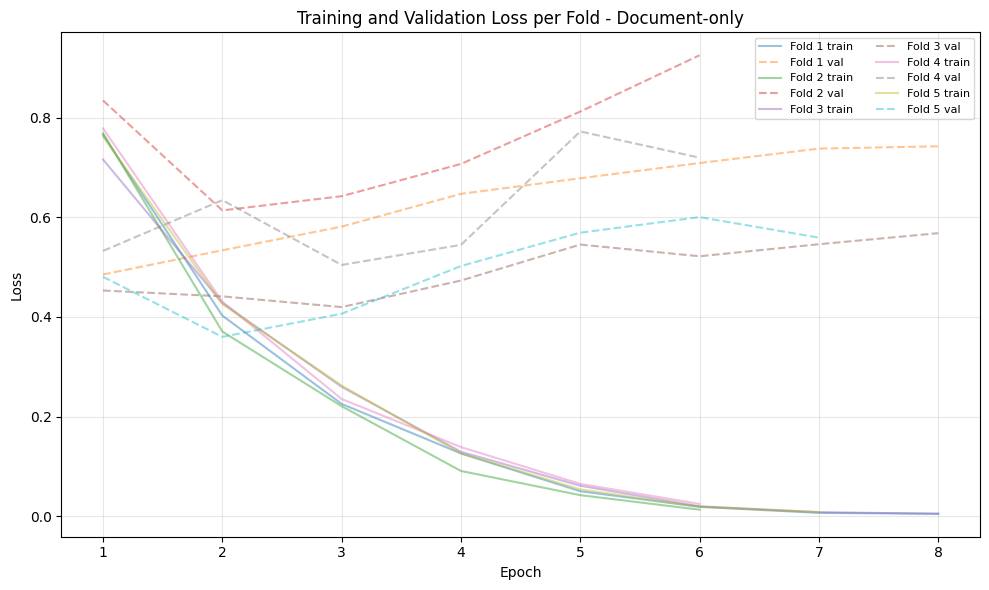

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_by_fold_Document-only.png


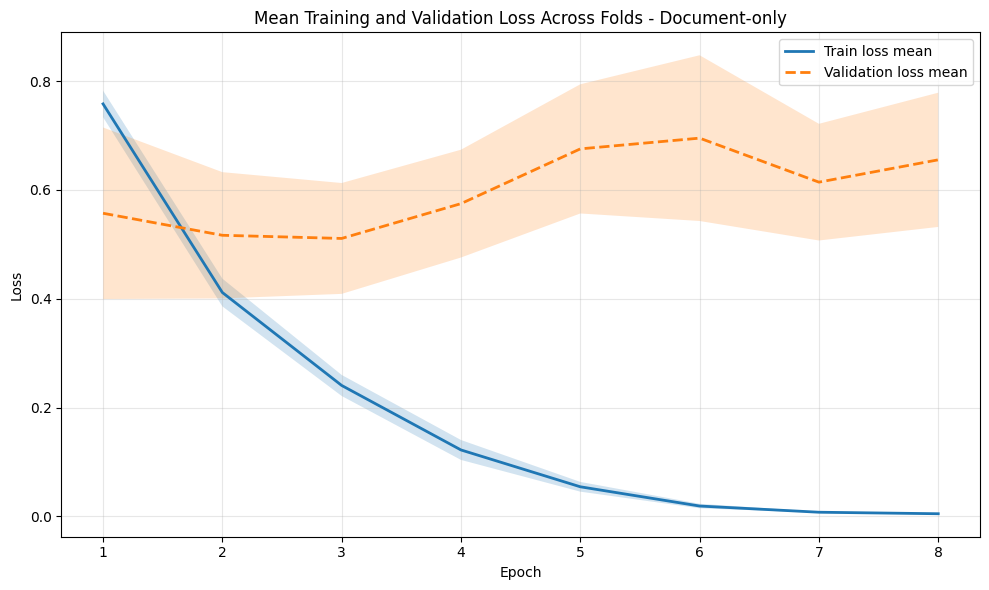

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_mean_std_Document-only.png


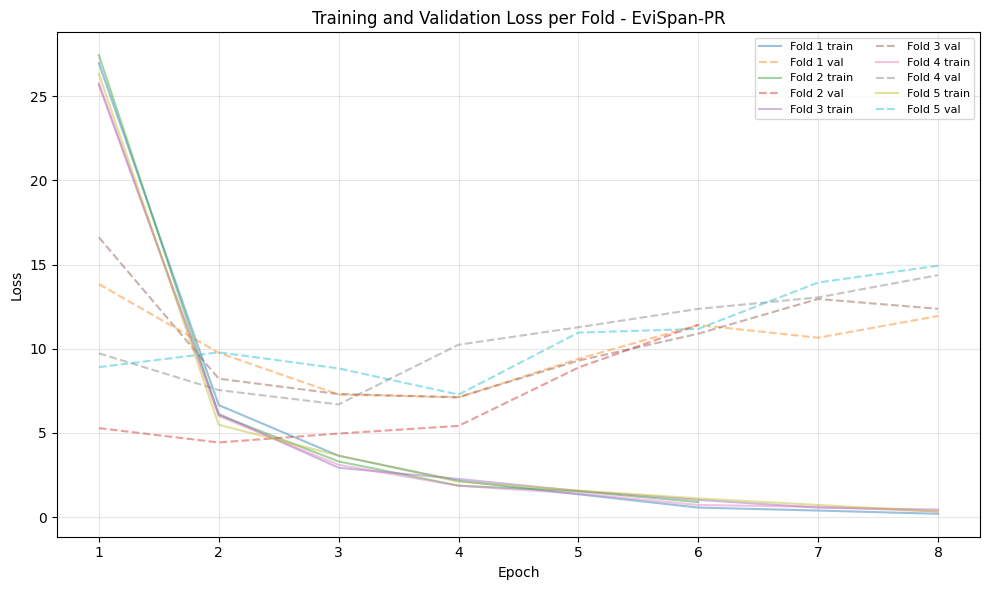

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_by_fold_EviSpan-PR.png


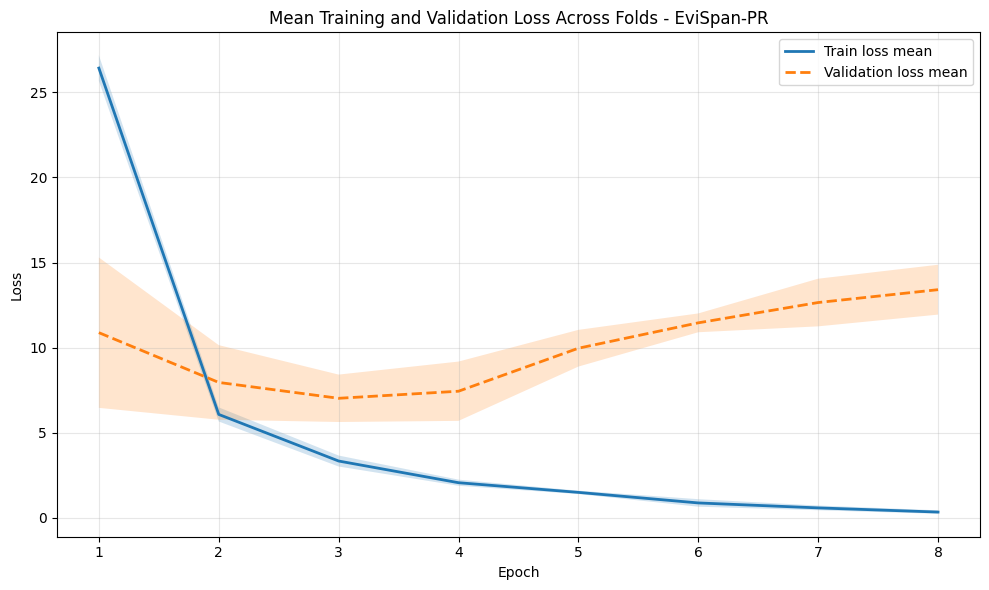

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_mean_std_EviSpan-PR.png


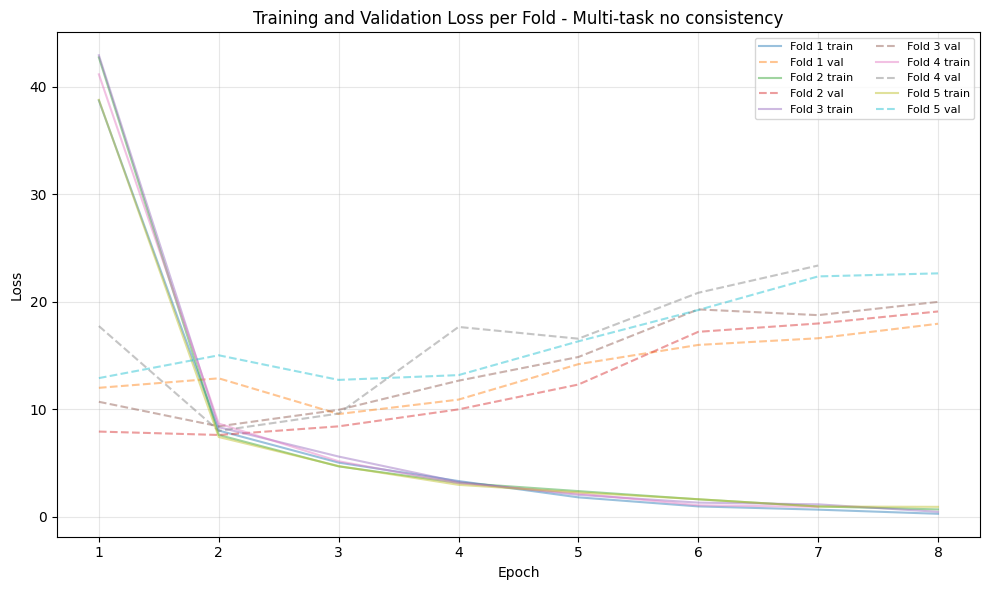

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_by_fold_Multi-task_no_consistency.png


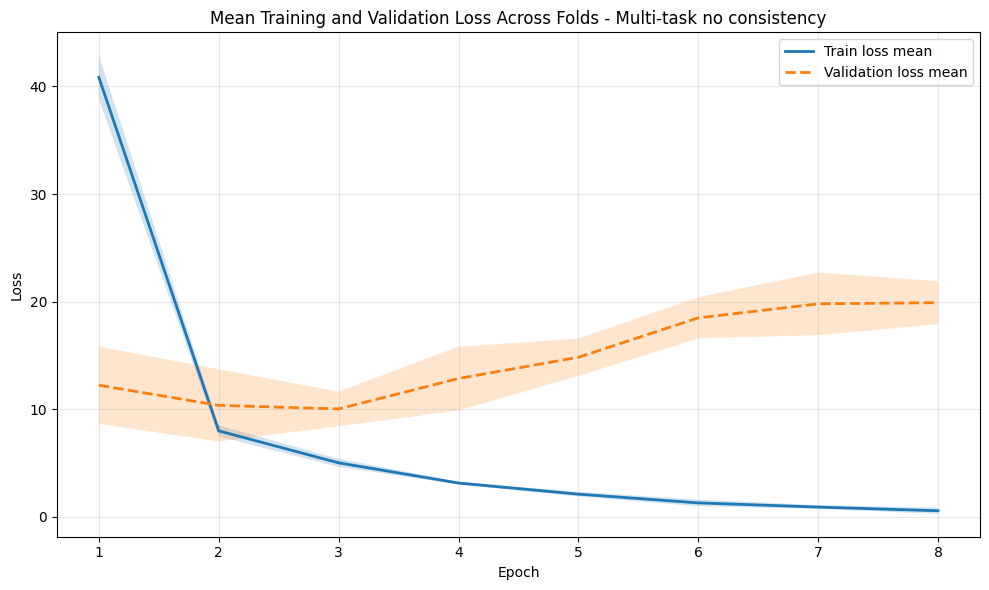

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_mean_std_Multi-task_no_consistency.png


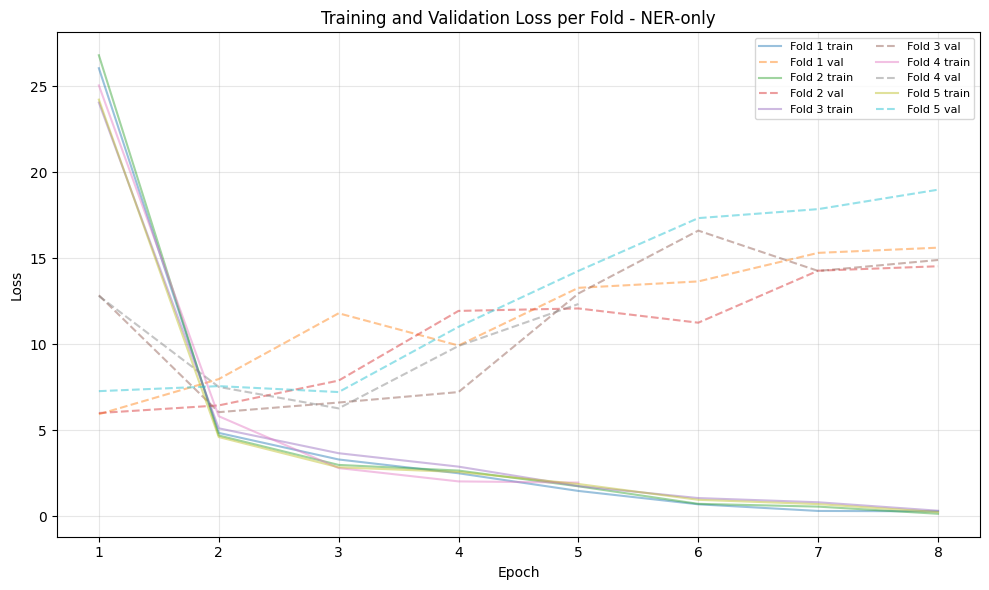

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_by_fold_NER-only.png


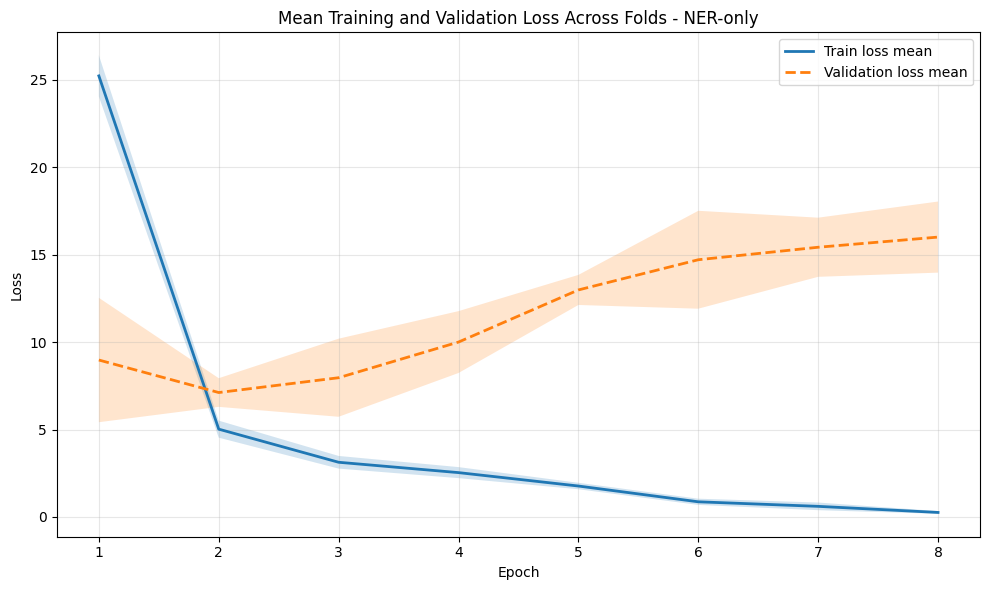

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_loss_curves_mean_std_NER-only.png


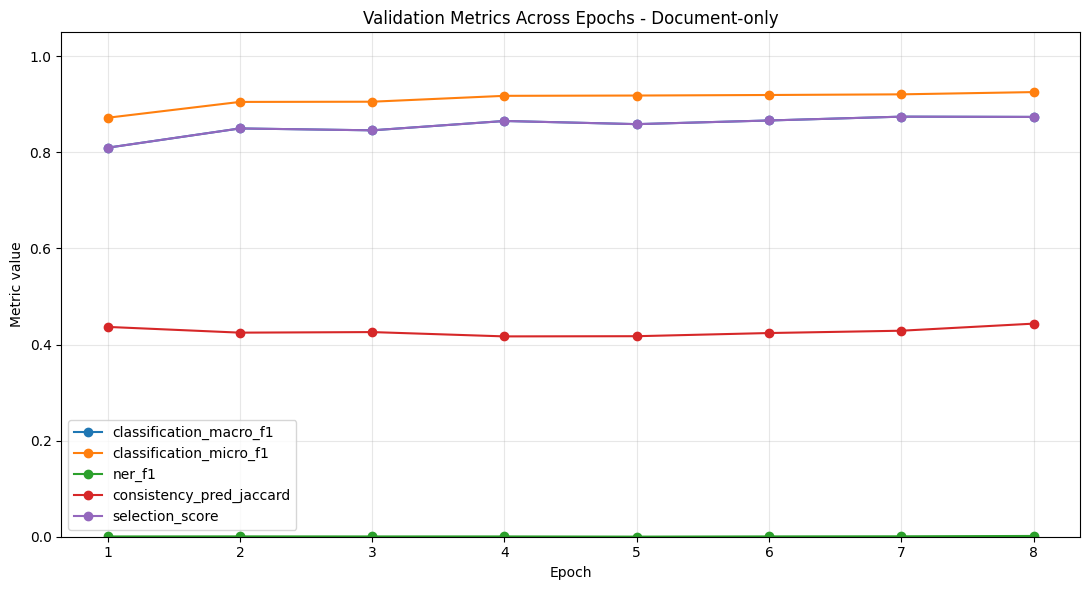

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_validation_metrics_Document-only.png


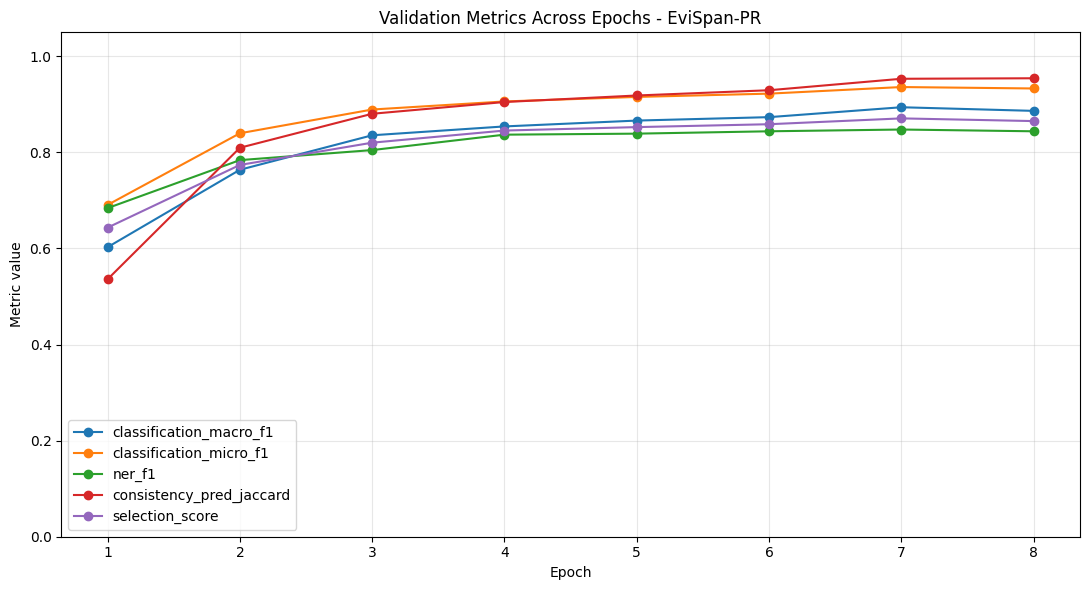

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_validation_metrics_EviSpan-PR.png


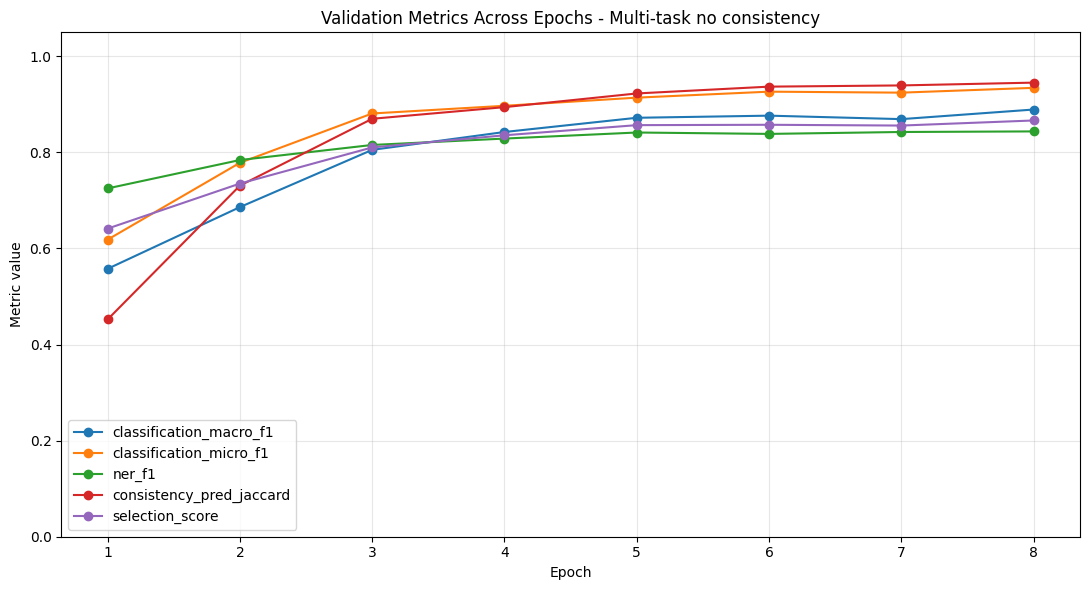

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_validation_metrics_Multi-task_no_consistency.png


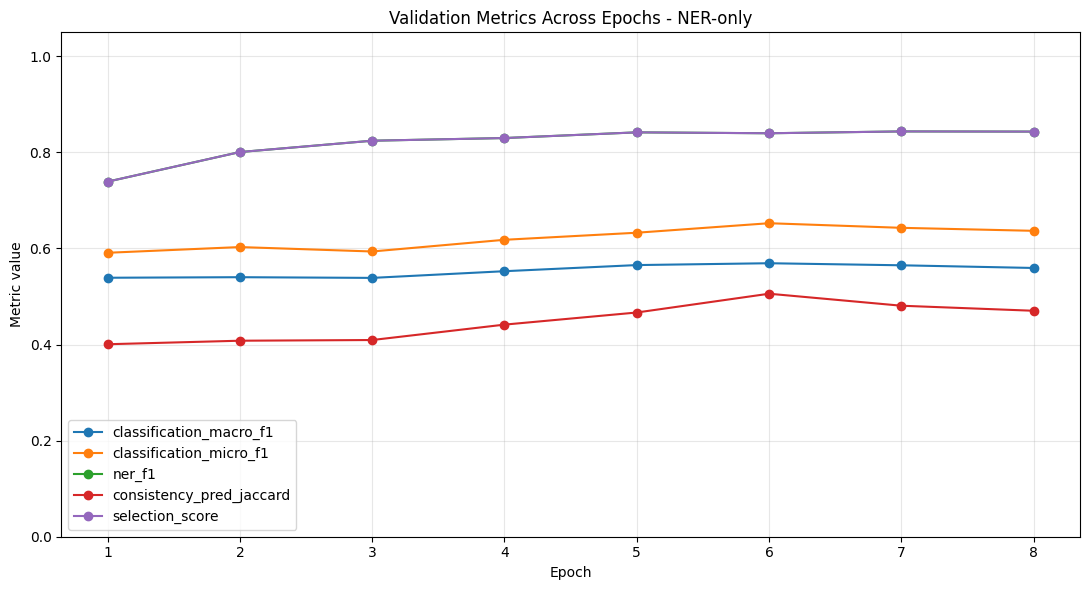

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_validation_metrics_NER-only.png


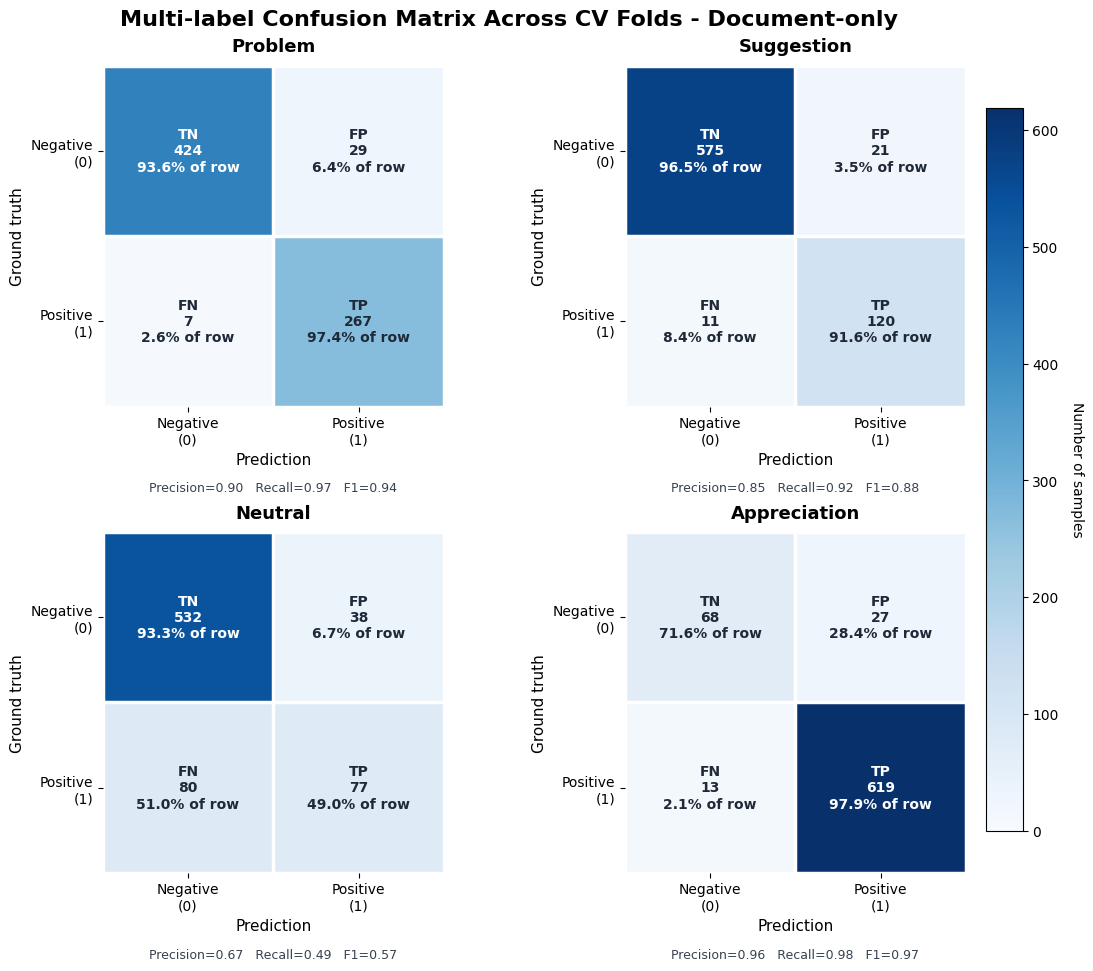

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_Document-only_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_Document-only_readable.pdf


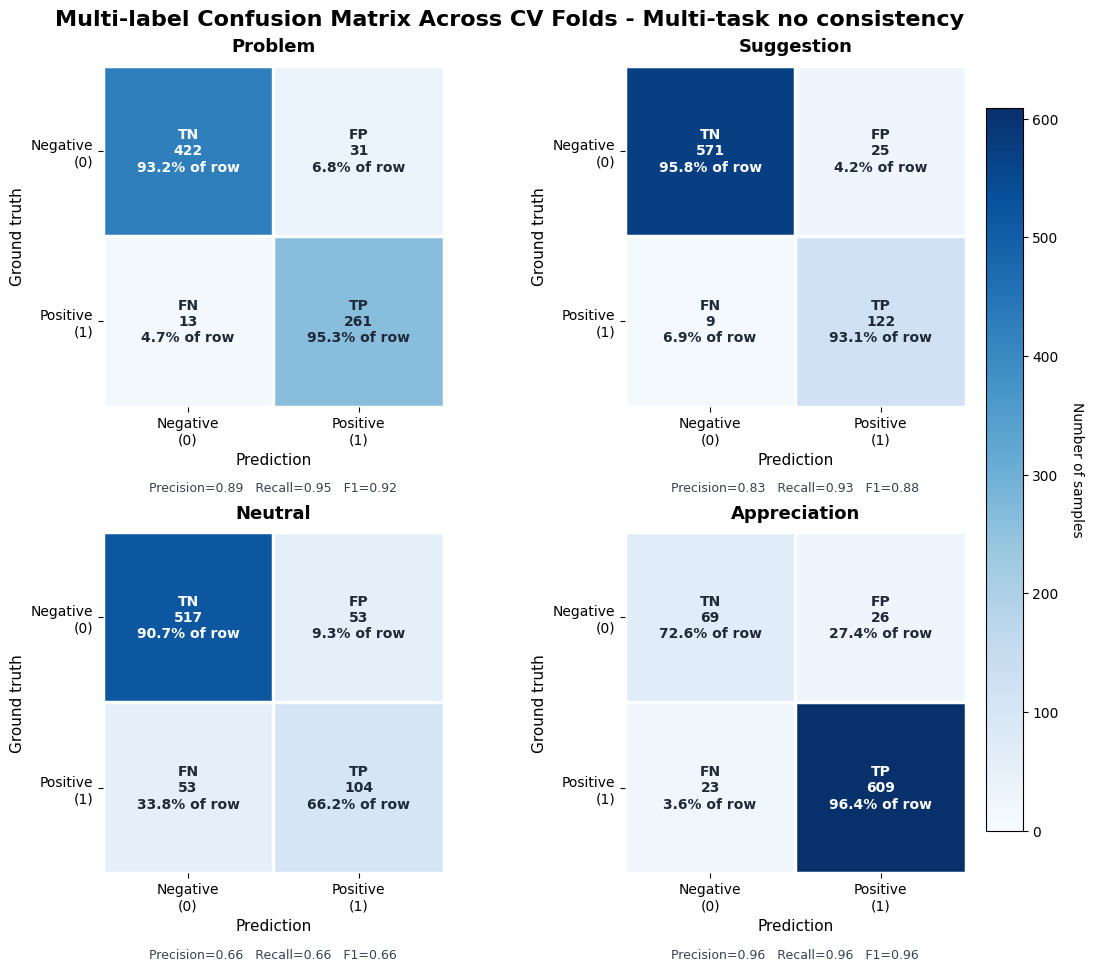

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_Multi-task_no_consistency_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_Multi-task_no_consistency_readable.pdf


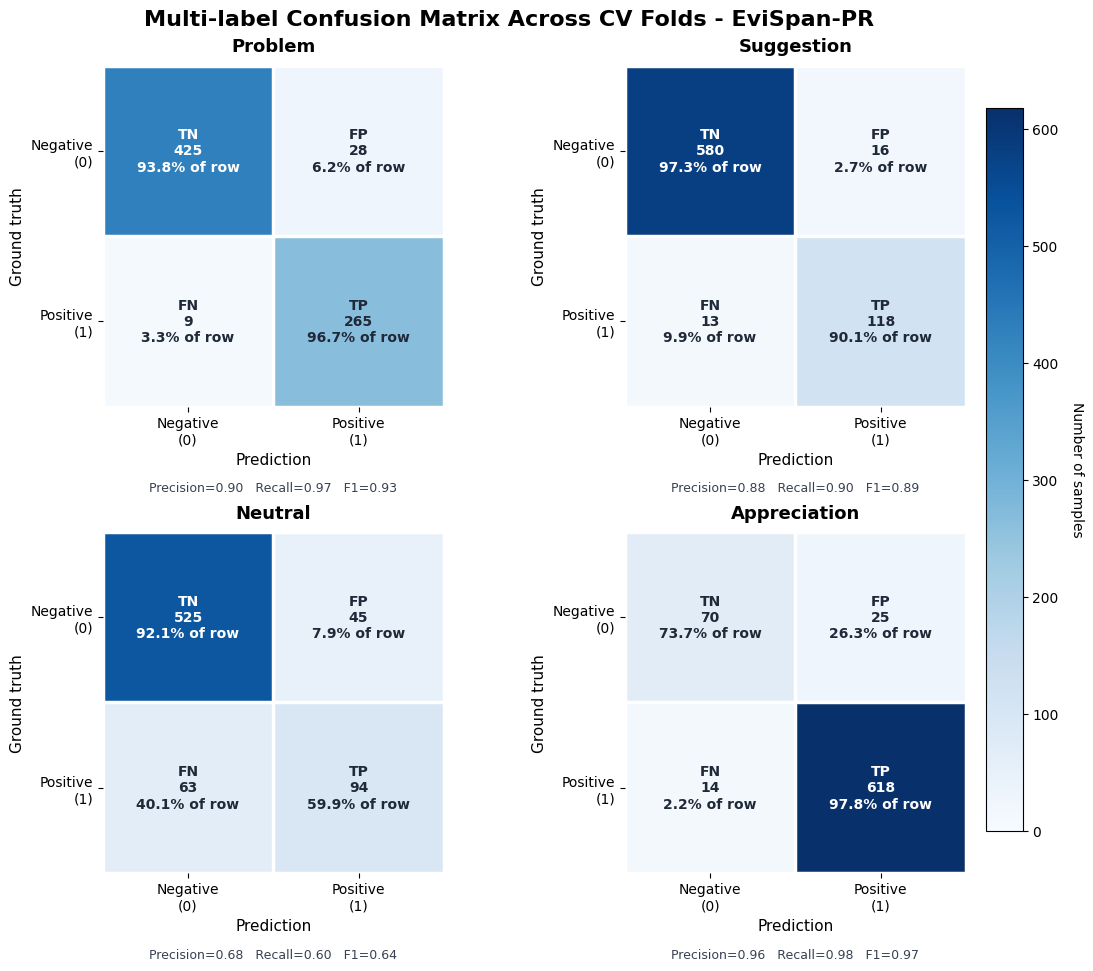

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_EviSpan-PR_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_multilabel_confusion_matrix_EviSpan-PR_readable.pdf


,model,label,tn,fp,fn,tp,precision,recall,f1
0,Document-only,Problem,424,29,7,267,0.902027,0.974453,0.936842
1,Document-only,Suggestion,575,21,11,120,0.851064,0.916031,0.882353
2,Document-only,Neutral,532,38,80,77,0.669565,0.490446,0.566176
3,Document-only,Appreciation,68,27,13,619,0.958204,0.979430,0.968701
4,Multi-task no consistency,Problem,422,31,13,261,0.893836,0.952555,0.922261
5,Multi-task no consistency,Suggestion,571,25,9,122,0.829932,0.931298,0.877698
6,Multi-task no consistency,Neutral,517,53,53,104,0.662420,0.662420,0.662420
7,Multi-task no consistency,Appreciation,69,26,23,609,0.959055,0.963608,0.961326
8,EviSpan-PR,Problem,425,28,9,265,0.904437,0.967153,0.934744
9,EviSpan-PR,Suggestion,580,16,13,118,0.880597,0.900763,0.890566


Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_multilabel_confusion_matrix_table.csv


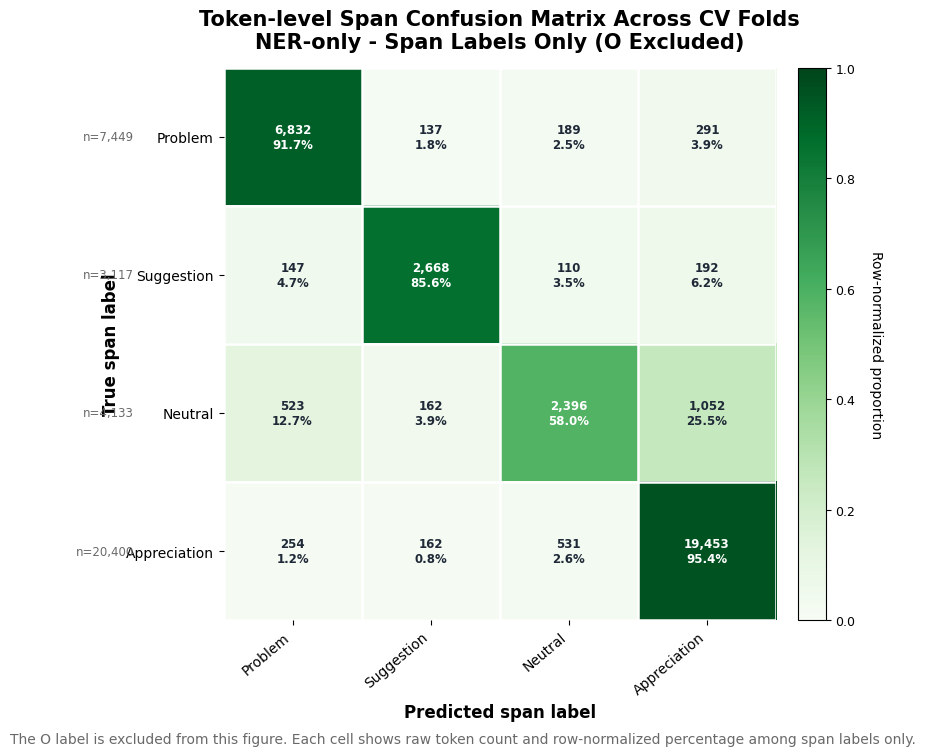

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_NER-only_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_NER-only_readable.pdf


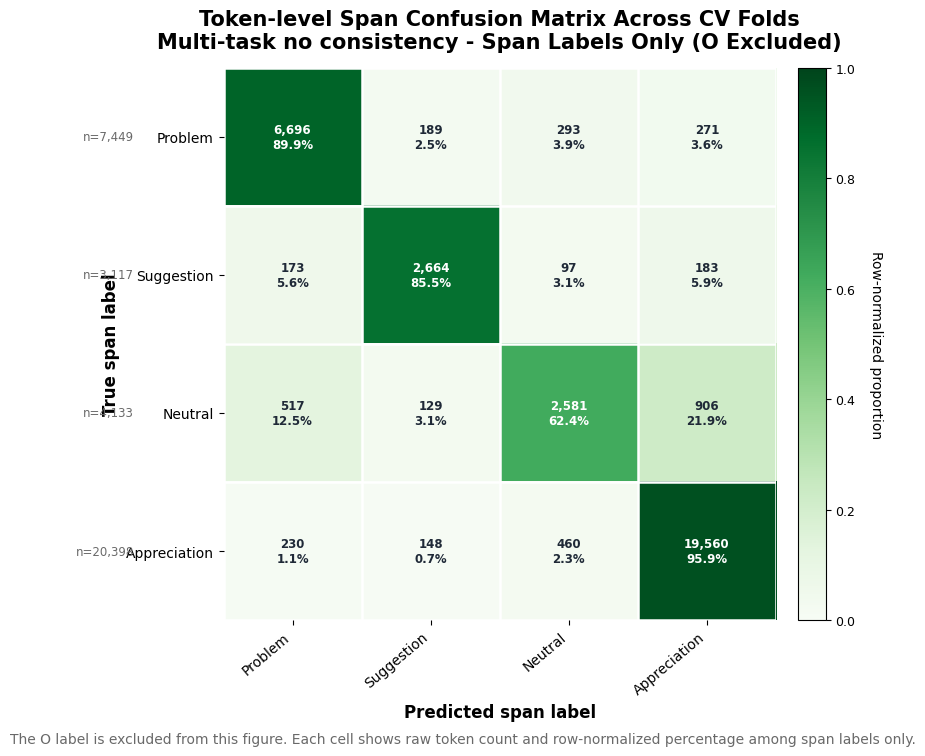

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_Multi-task_no_consistency_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_Multi-task_no_consistency_readable.pdf


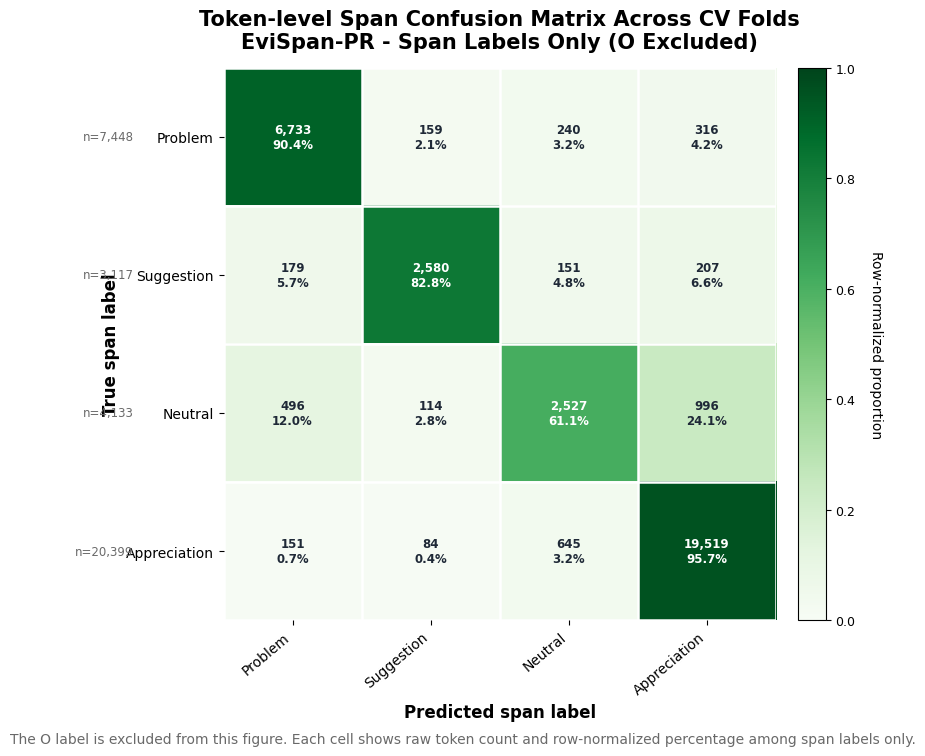

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_EviSpan-PR_readable.png
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/visualizations/cv_span_token_confusion_matrix_EviSpan-PR_readable.pdf


,true_label,model,pred_Problem,pred_Suggestion,pred_Neutral,pred_Appreciation
0,true_Problem,NER-only,6832,137,189,291
1,true_Suggestion,NER-only,147,2668,110,192
2,true_Neutral,NER-only,523,162,2396,1052
3,true_Appreciation,NER-only,254,162,531,19453
4,true_Problem,Multi-task no consistency,6696,189,293,271
5,true_Suggestion,Multi-task no consistency,173,2664,97,183
6,true_Neutral,Multi-task no consistency,517,129,2581,906
7,true_Appreciation,Multi-task no consistency,230,148,460,19560
8,true_Problem,EviSpan-PR,6733,159,240,316
9,true_Suggestion,EviSpan-PR,179,2580,151,207


Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_span_token_confusion_matrix_table.csv


In [15]:
# ============================================================
# 14. Multi-label nested cross-validation
# ============================================================

def make_multilabel_cv_splits(
    dataframe: pd.DataFrame,
    n_splits: int,
    seed: int,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    dataframe = dataframe.reset_index(drop=True)
    y = labels_to_multihot_matrix(dataframe)
    n_splits = min(int(n_splits), len(dataframe))
    if n_splits < 2:
        raise ValueError("n_splits must be at least 2.")

    splitter = MultilabelStratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )
    return list(splitter.split(np.zeros(len(dataframe)), y))


def make_inner_train_val_split(
    dataframe: pd.DataFrame,
    val_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    dataframe = dataframe.reset_index(drop=True)
    y = labels_to_multihot_matrix(dataframe)
    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=val_size,
        random_state=seed,
    )
    train_idx, val_idx = next(splitter.split(np.zeros(len(dataframe)), y))
    return dataframe.iloc[train_idx].reset_index(drop=True), dataframe.iloc[val_idx].reset_index(drop=True)


def train_one_cv_fold(
    model_name: str,
    variant_cfg: Dict[str, Any],
    inner_train_df: pd.DataFrame,
    inner_val_df: pd.DataFrame,
    outer_test_df: pd.DataFrame,
    tokenizer,
    cfg: Config,
    device: torch.device,
    fold_id: int,
) -> Tuple[Dict[str, float], pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_features_cv = encode_dataframe(inner_train_df, tokenizer, cfg)
    val_features_cv = encode_dataframe(inner_val_df, tokenizer, cfg)
    test_features_cv = encode_dataframe(outer_test_df, tokenizer, cfg)

    train_loader_cv = make_loader(train_features_cv, cfg.batch_size, shuffle=True)
    val_loader_cv = make_loader(val_features_cv, cfg.batch_size, shuffle=False)
    test_loader_cv = make_loader(test_features_cv, cfg.batch_size, shuffle=False)

    if cfg.use_ner_class_weights:
        ner_class_weights_cv = compute_ner_class_weights(
            features=train_features_cv,
            num_tags=len(NER_TAGS),
            max_weight=cfg.ner_class_weight_max,
            o_weight=cfg.ner_o_class_weight,
        )
    else:
        ner_class_weights_cv = torch.ones(len(NER_TAGS), dtype=torch.float)

    model_cv = EviSpanPR(
        model_name=cfg.model_name,
        num_labels_cls=len(LABELS),
        num_ner_tags=len(NER_TAGS),
        cls_pos_weight=compute_pos_weight(train_features_cv),
        ner_class_weights=ner_class_weights_cv,
        use_crf=cfg.use_crf,
        crf_enforce_biluo_constraints=cfg.crf_enforce_biluo_constraints,
        auxiliary_token_ce_loss_weight=cfg.auxiliary_token_ce_loss_weight,
        evidence_pooling=cfg.evidence_pooling,
        logsumexp_temperature=cfg.logsumexp_temperature,
        consistency_type=variant_cfg.get("consistency_type", cfg.consistency_type),
        consistency_confidence_threshold=cfg.consistency_confidence_threshold,
    ).to(device)

    model_cv, history_df, best_thresholds_cv = train_model_with_validation(
        model=model_cv,
        train_loader=train_loader_cv,
        val_loader=val_loader_cv,
        val_features=val_features_cv,
        variant_cfg=variant_cfg,
        cfg=cfg,
        device=device,
        model_name=model_name,
        fold=fold_id,
    )

    test_pred_cv = predict_model(
        model_cv,
        test_loader_cv,
        test_features_cv,
        device,
        cls_loss_weight=variant_cfg["cls_loss_weight"],
        ner_loss_weight=variant_cfg["ner_loss_weight"],
        consistency_loss_weight=variant_cfg["consistency_loss_weight"],
    )

    test_metrics_cv = evaluate_predictions_multilabel(test_pred_cv, best_thresholds_cv, prefix="test_")

    # Mask metrics not applicable to baseline variants.
    if not variant_cfg["report_classification"]:
        for key in list(test_metrics_cv.keys()):
            if key.startswith("test_classification") or key in {
                "test_hamming_loss",
                "test_subset_accuracy",
                "test_average_precision_micro",
                "test_average_precision_macro",
                "test_roc_auc_micro",
                "test_roc_auc_macro",
            }:
                test_metrics_cv[key] = np.nan

    if not variant_cfg["report_span"]:
        for key in list(test_metrics_cv.keys()):
            if key.startswith("test_ner"):
                test_metrics_cv[key] = np.nan

    if not variant_cfg["report_consistency"]:
        for key in list(test_metrics_cv.keys()):
            if key.startswith("test_consistency"):
                test_metrics_cv[key] = np.nan

    test_metrics_cv.update({
        "fold": fold_id,
        "model": model_name,
        "threshold_problem": float(best_thresholds_cv[LABEL2ID["Problem"]]),
        "threshold_suggestion": float(best_thresholds_cv[LABEL2ID["Suggestion"]]),
        "threshold_neutral": float(best_thresholds_cv[LABEL2ID["Neutral"]]),
        "threshold_appreciation": float(best_thresholds_cv[LABEL2ID["Appreciation"]]),
    })

    # ============================================================
    # Save fold-level document classification predictions.
    # This is needed for multi-label one-vs-rest confusion matrices
    # aggregated across CV folds.
    # ============================================================
    y_test_true = test_pred_cv["cls_true"]
    y_test_prob = test_pred_cv["cls_probs"]
    y_test_pred = (
        y_test_prob >= best_thresholds_cv.reshape(1, -1)
    ).astype(int)

    fold_prediction_rows = []
    for sample_idx in range(len(y_test_true)):
        row = {
            "fold": fold_id,
            "model": model_name,
            "sample_index": sample_idx,
        }
        for j, label in enumerate(LABELS):
            label_key = label.lower()
            row[f"true_{label_key}"] = int(y_test_true[sample_idx, j])
            row[f"prob_{label_key}"] = float(y_test_prob[sample_idx, j])
            row[f"pred_{label_key}"] = int(y_test_pred[sample_idx, j])
        fold_predictions_df = None
        fold_prediction_rows.append(row)

    fold_predictions_df = pd.DataFrame(fold_prediction_rows)

    # ============================================================
    # Save token-level span predictions.
    # These support token-level confusion matrix for BILUO span extraction.
    # Tags are collapsed to base labels: O, Problem, Suggestion, Neutral, Appreciation.
    # ============================================================
    span_token_rows = []
    for sample_idx, (true_tags, pred_tags) in enumerate(
        zip(test_pred_cv["true_biluo"], test_pred_cv["pred_biluo"])
    ):
        for token_idx, (true_tag, pred_tag) in enumerate(zip(true_tags, pred_tags)):
            true_label = biluo_to_base_label(true_tag)
            pred_label = biluo_to_base_label(pred_tag)
            span_token_rows.append({
                "fold": fold_id,
                "model": model_name,
                "sample_index": sample_idx,
                "token_index": token_idx,
                "true_label": true_label,
                "pred_label": pred_label,
            })

    fold_span_token_predictions_df = pd.DataFrame(span_token_rows)

    del model_cv
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return test_metrics_cv, history_df, fold_predictions_df, fold_span_token_predictions_df


def run_multilabel_cv_experiments(
    dataframe: pd.DataFrame,
    model_variants: Dict[str, Dict[str, Any]],
    tokenizer,
    cfg: Config,
    device: torch.device,
    selected_models: Optional[List[str]] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if selected_models is None:
        selected_models = ["EviSpan-PR"]

    dataframe = dataframe.reset_index(drop=True)
    outer_splits = make_multilabel_cv_splits(dataframe, cfg.cv_n_splits, cfg.seed)

    all_result_rows = []
    all_history = []
    all_fold_predictions = []
    all_span_token_predictions = []

    for fold_id, (outer_train_idx, outer_test_idx) in enumerate(outer_splits, start=1):
        print("=" * 80)
        print(f"Outer fold {fold_id}/{len(outer_splits)}")

        outer_train_df = dataframe.iloc[outer_train_idx].reset_index(drop=True)
        outer_test_df = dataframe.iloc[outer_test_idx].reset_index(drop=True)

        inner_train_df, inner_val_df = make_inner_train_val_split(
            outer_train_df,
            val_size=cfg.inner_val_size,
            seed=cfg.seed + fold_id,
        )

        for model_name in selected_models:
            print("-" * 80)
            print("Training:", model_name)
            result_row, history_df, fold_predictions_df, fold_span_token_predictions_df = train_one_cv_fold(
                model_name=model_name,
                variant_cfg=model_variants[model_name],
                inner_train_df=inner_train_df,
                inner_val_df=inner_val_df,
                outer_test_df=outer_test_df,
                tokenizer=tokenizer,
                cfg=cfg,
                device=device,
                fold_id=fold_id,
            )
            all_result_rows.append(result_row)
            all_history.append(history_df)
            all_fold_predictions.append(fold_predictions_df)
            all_span_token_predictions.append(fold_span_token_predictions_df)

    cv_results_df = pd.DataFrame(all_result_rows)
    cv_history_df = pd.concat(all_history, ignore_index=True) if all_history else pd.DataFrame()
    cv_fold_predictions_df = pd.concat(all_fold_predictions, ignore_index=True) if all_fold_predictions else pd.DataFrame()
    cv_span_token_predictions_df = pd.concat(all_span_token_predictions, ignore_index=True) if all_span_token_predictions else pd.DataFrame()
    return cv_results_df, cv_history_df, cv_fold_predictions_df, cv_span_token_predictions_df


# ============================================================
# 14B. Cross-validation visualization utilities
# ============================================================

def ensure_dir(path: str) -> str:
    os.makedirs(path, exist_ok=True)
    return path


def find_loss_columns(history_df: pd.DataFrame) -> Tuple[str, str]:
    train_candidates = ["train_loss", "train_total_loss", "loss_train"]
    val_candidates = ["val_loss", "validation_loss", "loss_val"]

    train_col = next((c for c in train_candidates if c in history_df.columns), None)
    val_col = next((c for c in val_candidates if c in history_df.columns), None)

    if train_col is None:
        raise ValueError(f"Cannot find train loss column. Available columns: {list(history_df.columns)}")
    if val_col is None:
        raise ValueError(f"Cannot find validation loss column. Available columns: {list(history_df.columns)}")

    return train_col, val_col


def plot_cv_loss_curves(
    cv_history_df: pd.DataFrame,
    output_dir: str,
    model_col: str = "model",
    fold_col: str = "fold",
    epoch_col: str = "epoch",
):
    output_dir = ensure_dir(output_dir)

    if cv_history_df.empty:
        print("No CV history available for loss visualization.")
        return

    train_col, val_col = find_loss_columns(cv_history_df)

    for model_name, model_df in cv_history_df.groupby(model_col):
        model_safe = str(model_name).replace(" ", "_").replace("/", "_").replace("+", "plus")

        # Individual fold curves
        plt.figure(figsize=(10, 6))
        for fold_id, fold_df in model_df.groupby(fold_col):
            fold_df = fold_df.sort_values(epoch_col)
            plt.plot(fold_df[epoch_col], fold_df[train_col], linestyle="-", alpha=0.45, label=f"Fold {fold_id} train")
            plt.plot(fold_df[epoch_col], fold_df[val_col], linestyle="--", alpha=0.45, label=f"Fold {fold_id} val")

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training and Validation Loss per Fold - {model_name}")
        plt.legend(fontsize=8, ncol=2)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        path = os.path.join(output_dir, f"cv_loss_curves_by_fold_{model_safe}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

        # Mean ± std curves
        grouped = (
            model_df.groupby(epoch_col)
            .agg(
                train_mean=(train_col, "mean"),
                train_std=(train_col, "std"),
                val_mean=(val_col, "mean"),
                val_std=(val_col, "std"),
            )
            .reset_index()
            .fillna(0.0)
        )

        epochs = grouped[epoch_col].to_numpy(dtype=float)
        train_mean = grouped["train_mean"].to_numpy(dtype=float)
        train_std = grouped["train_std"].to_numpy(dtype=float)
        val_mean = grouped["val_mean"].to_numpy(dtype=float)
        val_std = grouped["val_std"].to_numpy(dtype=float)

        plt.figure(figsize=(10, 6))
        plt.plot(epochs, train_mean, label="Train loss mean", linewidth=2)
        plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, alpha=0.20)
        plt.plot(epochs, val_mean, label="Validation loss mean", linewidth=2, linestyle="--")
        plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, alpha=0.20)

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Mean Training and Validation Loss Across Folds - {model_name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        path = os.path.join(output_dir, f"cv_loss_curves_mean_std_{model_safe}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)


def plot_cv_validation_metrics(
    cv_history_df: pd.DataFrame,
    output_dir: str,
    metrics: Optional[List[str]] = None,
    model_col: str = "model",
    epoch_col: str = "epoch",
):
    output_dir = ensure_dir(output_dir)

    if cv_history_df.empty:
        print("No CV history available for validation metric visualization.")
        return

    if metrics is None:
        metrics = [
            "val_classification_macro_f1",
            "val_classification_micro_f1",
            "val_ner_f1",
            "val_consistency_pred_jaccard",
            "selection_score",
        ]

    available_metrics = [m for m in metrics if m in cv_history_df.columns]
    if not available_metrics:
        print("No validation metric columns found for plotting.")
        return

    for model_name, model_df in cv_history_df.groupby(model_col):
        model_safe = str(model_name).replace(" ", "_").replace("/", "_").replace("+", "plus")

        plt.figure(figsize=(11, 6))
        for metric in available_metrics:
            grouped = model_df.groupby(epoch_col)[metric].mean().reset_index()
            plt.plot(grouped[epoch_col], grouped[metric], marker="o", label=metric.replace("val_", ""))

        plt.xlabel("Epoch")
        plt.ylabel("Metric value")
        plt.title(f"Validation Metrics Across Epochs - {model_name}")
        plt.ylim(0, 1.05)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        path = os.path.join(output_dir, f"cv_validation_metrics_{model_safe}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", path)


def extract_y_true_pred_from_cv_predictions(
    cv_fold_predictions_df: pd.DataFrame,
    model_name: str,
) -> Tuple[np.ndarray, np.ndarray]:
    model_df = cv_fold_predictions_df[cv_fold_predictions_df["model"] == model_name].copy()
    y_true, y_pred = [], []

    for _, row in model_df.iterrows():
        true_row, pred_row = [], []
        for label in LABELS:
            key = label.lower()
            true_row.append(int(row[f"true_{key}"]))
            pred_row.append(int(row[f"pred_{key}"]))
        y_true.append(true_row)
        y_pred.append(pred_row)

    return np.array(y_true), np.array(y_pred)


def plot_multilabel_confusion_matrices_cv(
    cv_fold_predictions_df: pd.DataFrame,
    output_dir: str,
):
    """
    Plot readable multi-label confusion matrices aggregated across CV folds.

    This version uses the helper from Section 12:
    _plot_multilabel_confusion_matrix_grid(...)
    """
    output_dir = ensure_dir(output_dir)

    if cv_fold_predictions_df.empty:
        print("No CV fold predictions available for classification confusion matrices.")
        return

    for model_name in cv_fold_predictions_df["model"].unique():
        if "MODEL_VARIANTS" in globals() and not MODEL_VARIANTS.get(model_name, {}).get("report_classification", True):
            continue

        y_true, y_pred = extract_y_true_pred_from_cv_predictions(cv_fold_predictions_df, model_name)
        if y_true.size == 0:
            continue

        matrices = multilabel_confusion_matrix(y_true, y_pred)

        model_safe = str(model_name).replace(" ", "_").replace("/", "_").replace("+", "plus")
        _plot_multilabel_confusion_matrix_grid(
            matrices=matrices,
            labels=LABELS,
            output_dir=output_dir,
            filename=f"cv_multilabel_confusion_matrix_{model_safe}_readable.png",
            title=f"Multi-label Confusion Matrix Across CV Folds - {model_name}",
            n_cols=2,
            cmap_name="Blues",
            dpi=300,
        )


def build_cv_confusion_matrix_table(cv_fold_predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    if cv_fold_predictions_df.empty:
        return pd.DataFrame(rows)

    for model_name in cv_fold_predictions_df["model"].unique():
        if "MODEL_VARIANTS" in globals() and not MODEL_VARIANTS.get(model_name, {}).get("report_classification", True):
            continue

        y_true, y_pred = extract_y_true_pred_from_cv_predictions(cv_fold_predictions_df, model_name)
        if y_true.size == 0:
            continue

        matrices = multilabel_confusion_matrix(y_true, y_pred)
        for label, matrix in zip(LABELS, matrices):
            tn, fp, fn, tp = matrix.ravel()
            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-12)
            rows.append({
                "model": model_name,
                "label": label,
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
                "precision": float(precision),
                "recall": float(recall),
                "f1": float(f1),
            })

    return pd.DataFrame(rows)


def plot_span_token_confusion_matrix_cv(
    cv_span_token_predictions_df: pd.DataFrame,
    output_dir: str,
    include_o: bool = False,
    save_including_o: bool = False,
):
    """
    Plot readable token-level span confusion matrices aggregated across CV folds.

    By default, the visualized CV token-level matrix excludes the dominant O
    label. This makes the confusion among evidence-span labels clearer for
    publication. Set include_o=True to make the main figure include O, or set
    save_including_o=True to also save an O-included diagnostic figure.
    """
    output_dir = ensure_dir(output_dir)

    if cv_span_token_predictions_df.empty:
        print("No CV span token predictions available for token-level confusion matrix.")
        return pd.DataFrame()

    all_labels = ["O"] + LABELS
    table_rows = []

    for model_name in cv_span_token_predictions_df["model"].unique():
        if "MODEL_VARIANTS" in globals() and not MODEL_VARIANTS.get(model_name, {}).get("report_span", True):
            continue

        model_df = cv_span_token_predictions_df[
            cv_span_token_predictions_df["model"] == model_name
        ]
        y_true = model_df["true_label"].tolist()
        y_pred = model_df["pred_label"].tolist()

        full_cm = confusion_matrix(y_true, y_pred, labels=all_labels)

        if include_o:
            plot_labels = all_labels
            plot_cm = full_cm
            title_suffix = ""
            cmap_name = "Blues"
            x_label = "Predicted token label"
            y_label = "True token label"
            note = None
        else:
            plot_labels = LABELS
            plot_cm = full_cm[1:, 1:]
            title_suffix = " - Span Labels Only (O Excluded)"
            cmap_name = "Greens"
            x_label = "Predicted span label"
            y_label = "True span label"
            note = (
                "The O label is excluded from this figure. Each cell shows raw token count "
                "and row-normalized percentage among span labels only."
            )

        cm_df = pd.DataFrame(
            plot_cm,
            index=[f"true_{x}" for x in plot_labels],
            columns=[f"pred_{x}" for x in plot_labels],
        )
        cm_df.insert(0, "model", model_name)
        table_rows.append(cm_df.reset_index().rename(columns={"index": "true_label"}))

        model_safe = _safe_filename(model_name)

        path = os.path.join(
            output_dir,
            f"cv_span_token_confusion_matrix_{model_safe}_readable.png",
        )
        pdf_path = os.path.splitext(path)[0] + ".pdf"

        _plot_readable_token_confusion_matrix(
            cm=plot_cm,
            labels=plot_labels,
            title=f"Token-level Span Confusion Matrix Across CV Folds\n{model_name}{title_suffix}",
            output_path_png=path,
            output_path_pdf=pdf_path,
            cmap_name=cmap_name,
            xlabel=x_label,
            ylabel=y_label,
            note=note,
        )

        if save_including_o and not include_o:
            path_with_o = os.path.join(
                output_dir,
                f"cv_span_token_confusion_matrix_{model_safe}_including_O_readable.png",
            )
            pdf_path_with_o = os.path.splitext(path_with_o)[0] + ".pdf"

            _plot_readable_token_confusion_matrix(
                cm=full_cm,
                labels=all_labels,
                title=f"Token-level Span Confusion Matrix Across CV Folds\n{model_name} - Including O",
                output_path_png=path_with_o,
                output_path_pdf=pdf_path_with_o,
                cmap_name="Blues",
                xlabel="Predicted token label",
                ylabel="True token label",
            )

    if table_rows:
        return pd.concat(table_rows, ignore_index=True)
    return pd.DataFrame()


if CFG.run_multilabel_cv or CFG.run_ablation_cv:
    selected = list(CFG.selected_models_for_cv) if CFG.run_ablation_cv else ["EviSpan-PR"]

    cv_results_df, cv_history_df, cv_fold_predictions_df, cv_span_token_predictions_df = run_multilabel_cv_experiments(
        dataframe=df,
        model_variants=MODEL_VARIANTS,
        tokenizer=tokenizer,
        cfg=CFG,
        device=device,
        selected_models=selected,
    )

    cv_dir = os.path.join(CFG.output_dir, "multilabel_cv")
    os.makedirs(cv_dir, exist_ok=True)

    cv_results_path = os.path.join(cv_dir, "cv_results_by_fold.csv")
    cv_history_path = os.path.join(cv_dir, "cv_training_history.csv")
    cv_fold_predictions_path = os.path.join(cv_dir, "cv_fold_predictions.csv")
    cv_span_token_predictions_path = os.path.join(cv_dir, "cv_span_token_predictions.csv")

    cv_results_df.to_csv(cv_results_path, index=False, encoding="utf-8")
    cv_history_df.to_csv(cv_history_path, index=False, encoding="utf-8")
    cv_fold_predictions_df.to_csv(cv_fold_predictions_path, index=False, encoding="utf-8")
    cv_span_token_predictions_df.to_csv(cv_span_token_predictions_path, index=False, encoding="utf-8")

    print("Saved:", cv_results_path)
    print("Saved:", cv_history_path)
    print("Saved:", cv_fold_predictions_path)
    print("Saved:", cv_span_token_predictions_path)
    display(cv_results_df)

    # Cross-validation visualizations
    cv_visual_dir = os.path.join(cv_dir, "visualizations")
    plot_cv_loss_curves(cv_history_df, cv_visual_dir)
    plot_cv_validation_metrics(cv_history_df, cv_visual_dir)
    plot_multilabel_confusion_matrices_cv(cv_fold_predictions_df, cv_visual_dir)

    cv_confusion_table = build_cv_confusion_matrix_table(cv_fold_predictions_df)
    if not cv_confusion_table.empty:
        display(cv_confusion_table)
        cv_confusion_table_path = os.path.join(cv_dir, "cv_multilabel_confusion_matrix_table.csv")
        cv_confusion_table.to_csv(cv_confusion_table_path, index=False, encoding="utf-8")
        print("Saved:", cv_confusion_table_path)

    cv_span_token_confusion_table = plot_span_token_confusion_matrix_cv(cv_span_token_predictions_df, cv_visual_dir)
    if not cv_span_token_confusion_table.empty:
        display(cv_span_token_confusion_table)
        cv_span_token_confusion_path = os.path.join(cv_dir, "cv_span_token_confusion_matrix_table.csv")
        cv_span_token_confusion_table.to_csv(cv_span_token_confusion_path, index=False, encoding="utf-8")
        print("Saved:", cv_span_token_confusion_path)
else:
    print("Cross-validation disabled. Set CFG.run_multilabel_cv=True or CFG.run_ablation_cv=True to run.")


In [16]:
# ============================================================
# 15. Paper-ready reporting
# ============================================================

def mean_std_text(values: pd.Series, digits: int = 4) -> str:
    values = pd.to_numeric(values, errors="coerce").dropna()
    if len(values) == 0:
        return "-"
    mean = values.mean()
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    return f"{mean:.{digits}f} ± {std:.{digits}f}"


def summarize_cv_metric(cv_results_df: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    for model_name, group in cv_results_df.groupby("model"):
        values = pd.to_numeric(group[metric], errors="coerce").dropna()
        rows.append({
            "model": model_name,
            "metric": metric,
            "mean": values.mean() if len(values) else np.nan,
            "std": values.std(ddof=1) if len(values) > 1 else 0.0,
            "min": values.min() if len(values) else np.nan,
            "max": values.max() if len(values) else np.nan,
            "n_folds": len(values),
        })
    return pd.DataFrame(rows)


def build_paper_ready_table(
    cv_results_df: pd.DataFrame,
    classification_metric: str = "test_classification_macro_f1",
    span_metric: str = "test_ner_f1",
    consistency_metric: str = "test_consistency_pred_jaccard",
) -> pd.DataFrame:
    model_order = [
        "Document-only",
        "NER-only",
        "Multi-task no consistency",
        "EviSpan-PR",
    ]
    rows = []
    for model_name in model_order:
        group = cv_results_df[cv_results_df["model"] == model_name]
        if group.empty:
            continue
        rows.append({
            "Model": model_name,
            "Classification Macro-F1": mean_std_text(group[classification_metric]) if classification_metric in group else "-",
            "Span F1": mean_std_text(group[span_metric]) if span_metric in group else "-",
            "Consistency": mean_std_text(group[consistency_metric]) if consistency_metric in group else "-",
        })
    return pd.DataFrame(rows)


def build_paper_ready_table_from_single_split(test_metrics: Dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame([
        {"Model": "Document-only", "Classification Macro-F1": "-", "Span F1": "-", "Consistency": "-"},
        {"Model": "NER-only", "Classification Macro-F1": "-", "Span F1": "-", "Consistency": "-"},
        {"Model": "Multi-task no consistency", "Classification Macro-F1": "-", "Span F1": "-", "Consistency": "-"},
        {
            "Model": "EviSpan-PR",
            "Classification Macro-F1": f"{test_metrics.get('test_classification_macro_f1', np.nan):.4f}",
            "Span F1": f"{test_metrics.get('test_ner_f1', np.nan):.4f}",
            "Consistency": f"{test_metrics.get('test_consistency_pred_jaccard', np.nan):.4f}",
        },
    ])


# Build paper table from CV if available; otherwise from single split if available.
if "cv_results_df" in globals() and not cv_results_df.empty:
    paper_table = build_paper_ready_table(cv_results_df)
    cv_summary_rows = []
    metrics_for_summary = [
        "test_classification_micro_f1",
        "test_classification_macro_f1",
        "test_classification_weighted_f1",
        "test_classification_samples_f1",
        "test_hamming_loss",
        "test_subset_accuracy",
        "test_average_precision_micro",
        "test_average_precision_macro",
        "test_ner_precision",
        "test_ner_recall",
        "test_ner_f1",
        "test_consistency_pred_jaccard",
        "test_consistency_gold_aware_coverage",
    ]
    for metric in metrics_for_summary:
        if metric in cv_results_df.columns:
            cv_summary_rows.append(summarize_cv_metric(cv_results_df, metric))
    cv_summary_detailed = pd.concat(cv_summary_rows, ignore_index=True) if cv_summary_rows else pd.DataFrame()

    report_dir = os.path.join(CFG.output_dir, "multilabel_cv")
    os.makedirs(report_dir, exist_ok=True)
    paper_table_path = os.path.join(report_dir, "paper_ready_table.csv")
    cv_summary_path = os.path.join(report_dir, "cv_summary_detailed.csv")
    paper_table.to_csv(paper_table_path, index=False, encoding="utf-8")
    cv_summary_detailed.to_csv(cv_summary_path, index=False, encoding="utf-8")
    print("Saved:", paper_table_path)
    print("Saved:", cv_summary_path)
    display(paper_table)
    display(cv_summary_detailed)

elif "test_metrics" in globals():
    paper_table = build_paper_ready_table_from_single_split(test_metrics)
    paper_table_path = os.path.join(CFG.output_dir, "paper_ready_table_single_split.csv")
    paper_table.to_csv(paper_table_path, index=False, encoding="utf-8")
    print("Saved:", paper_table_path)
    display(paper_table)
else:
    print("No evaluation results found. Run single split or CV first.")

Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/paper_ready_table.csv
Saved: /home/jupyter-sigitpurnomo/research/peer-review/output/evispan_pr_outputs_crf_tuned_final/multilabel_cv/cv_summary_detailed.csv


,Model,Classification Macro-F1,Span F1,Consistency
0,Document-only,0.8389 ± 0.0244,-,-
1,NER-only,-,0.8487 ± 0.0249,-
2,Multi-task no consistency,0.8570 ± 0.0193,0.8496 ± 0.0336,0.9288 ± 0.0318
3,EviSpan-PR,0.8575 ± 0.0144,0.8555 ± 0.0301,0.9305 ± 0.0219


,model,metric,mean,std,min,max,n_folds
0,Document-only,test_classification_micro_f1,0.905882,0.018956,0.877756,0.924731,5
1,EviSpan-PR,test_classification_micro_f1,0.911469,0.012049,0.891616,0.924370,5
2,Multi-task no consistency,test_classification_micro_f1,0.904341,0.018619,0.877953,0.927966,5
3,NER-only,test_classification_micro_f1,NaN,0.000000,NaN,NaN,0
4,Document-only,test_classification_macro_f1,0.838888,0.024378,0.810476,0.867283,5
5,EviSpan-PR,test_classification_macro_f1,0.857472,0.014380,0.836966,0.876272,5
6,Multi-task no consistency,test_classification_macro_f1,0.856985,0.019266,0.830815,0.882648,5
7,NER-only,test_classification_macro_f1,NaN,0.000000,NaN,NaN,0
8,Document-only,test_classification_weighted_f1,0.899370,0.017210,0.876413,0.917103,5
9,EviSpan-PR,test_classification_weighted_f1,0.908887,0.012675,0.888676,0.921420,5


In [17]:
# ============================================================
# 16. Error analysis utilities
# ============================================================

def span_key(span: Dict[str, Any]) -> Tuple[int, int, str]:
    return (int(span["start"]), int(span["end"]), normalize_label(span["label"]))


def spans_overlap(a: Dict[str, Any], b: Dict[str, Any]) -> bool:
    label_a = normalize_label(a.get("label"))
    label_b = normalize_label(b.get("label"))
    return label_a == label_b and char_overlap(int(a["start"]), int(a["end"]), int(b["start"]), int(b["end"]))


def true_spans_from_features(features: List[Dict[str, Any]]) -> List[List[Dict[str, Any]]]:
    out = []
    for f in features:
        spans = []
        for s in f["spans"]:
            label = normalize_label(s.get("label"))
            if label not in LABEL2ID:
                continue
            spans.append({
                "start": int(s["start"]),
                "end": int(s["end"]),
                "label": label,
                "text": s.get("text", f["text"][int(s["start"]):int(s["end"])]),
            })
        out.append(spans)
    return out


def predicted_spans_from_prediction(pred: Dict[str, Any], features: List[Dict[str, Any]]) -> List[List[Dict[str, Any]]]:
    pred_spans = []
    example_indices = pred.get("example_indices", list(range(len(pred["ner_pred_ids"]))))

    for pred_ids, true_ids, example_idx in zip(pred["ner_pred_ids"], pred["ner_true_ids"], example_indices):
        f = features[int(example_idx)]
        spans = decode_biluo_to_spans(
            text=f["text"],
            offsets=f["offset_mapping"],
            tag_ids=pred_ids,
            true_tag_ids_for_mask=true_ids,
        )
        pred_spans.append(spans)
    return pred_spans


def summarize_spans(spans: List[Dict[str, Any]], max_text_len: int = 80) -> str:
    parts = []
    for s in spans:
        label = normalize_label(s.get("label"))
        if label not in LABEL2ID:
            continue
        txt = str(s.get("text", "")).replace("\n", " ")
        if len(txt) > max_text_len:
            txt = txt[:max_text_len] + "..."
        parts.append(f'{label} [{int(s["start"])}:{int(s["end"])}] "{txt}"')
    return " | ".join(parts)


def build_error_analysis_df(
    features: List[Dict[str, Any]],
    cls_true: np.ndarray,
    cls_prob: np.ndarray,
    cls_pred: np.ndarray,
    true_spans: List[List[Dict[str, Any]]],
    pred_spans: List[List[Dict[str, Any]]],
) -> pd.DataFrame:
    rows = []
    for i, f in enumerate(features):
        true_doc = {LABELS[j] for j, v in enumerate(cls_true[i]) if v == 1}
        pred_doc = {LABELS[j] for j, v in enumerate(cls_pred[i]) if v == 1}

        true_span_set = {span_key(s) for s in true_spans[i]}
        pred_span_set = {span_key(s) for s in pred_spans[i]}

        exact_tp = true_span_set & pred_span_set
        missing = true_span_set - pred_span_set
        extra = pred_span_set - true_span_set

        partial_matches = []
        for ts in true_spans[i]:
            for ps in pred_spans[i]:
                if span_key(ts) != span_key(ps) and spans_overlap(ts, ps):
                    partial_matches.append({
                        "true": span_key(ts),
                        "pred": span_key(ps),
                    })

        pred_span_labels = {normalize_label(s["label"]) for s in pred_spans[i] if normalize_label(s.get("label")) in LABEL2ID}

        rows.append({
            "id": f["id"],
            "text": f["text"],
            "true_doc_labels": json.dumps(sorted(true_doc, key=lambda x: LABEL2ID[x]), ensure_ascii=False),
            "pred_doc_labels": json.dumps(sorted(pred_doc, key=lambda x: LABEL2ID[x]), ensure_ascii=False),
            "doc_false_negative": json.dumps(sorted(true_doc - pred_doc, key=lambda x: LABEL2ID[x]), ensure_ascii=False),
            "doc_false_positive": json.dumps(sorted(pred_doc - true_doc, key=lambda x: LABEL2ID[x]), ensure_ascii=False),
            "doc_exact_match": bool(true_doc == pred_doc),
            "pred_probs": json.dumps({LABELS[j]: float(cls_prob[i, j]) for j in range(len(LABELS))}, ensure_ascii=False),
            "true_span_summary": summarize_spans(true_spans[i]),
            "pred_span_summary": summarize_spans(pred_spans[i]),
            "n_true_spans": len(true_spans[i]),
            "n_pred_spans": len(pred_spans[i]),
            "n_exact_span_tp": len(exact_tp),
            "n_missing_spans": len(missing),
            "n_extra_spans": len(extra),
            "n_partial_overlap_matches": len(partial_matches),
            "partial_overlap_matches": json.dumps(partial_matches, ensure_ascii=False),
            "doc_span_pred_mismatch": json.dumps(sorted(pred_doc.symmetric_difference(pred_span_labels), key=lambda x: LABEL2ID[x]), ensure_ascii=False),
        })
    return pd.DataFrame(rows)


if "test_pred" in globals() and "y_test_pred" in globals():
    test_true_spans = true_spans_from_features(test_features)
    test_pred_spans = predicted_spans_from_prediction(test_pred, test_features)
    error_df = build_error_analysis_df(
        features=test_features,
        cls_true=y_test_true,
        cls_prob=y_test_prob,
        cls_pred=y_test_pred,
        true_spans=test_true_spans,
        pred_spans=test_pred_spans,
    )
    display(error_df.head())
    error_path = os.path.join(CFG.output_dir, "error_analysis_test.csv")
    error_df.to_csv(error_path, index=False, encoding="utf-8")
    print("Saved:", error_path)
else:
    print("Run single-split evaluation first to generate error analysis.")

Run single-split evaluation first to generate error analysis.


In [18]:
# ============================================================
# 17. Inference helper for a new comment
# ============================================================

def encode_single_text(text: str, tokenizer, cfg: Config) -> Dict[str, Any]:
    enc = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=cfg.max_length,
        return_offsets_mapping=True,
    )
    sequence_ids = enc.sequence_ids() if hasattr(enc, "sequence_ids") else [None] * len(enc["offset_mapping"])
    labels_ner_mask = []
    for offset, seq_id in zip(enc["offset_mapping"], sequence_ids):
        labels_ner_mask.append(-100 if seq_id is None or tuple(offset) == (0, 0) else TAG2ID["O"])

    item = {
        "text": text,
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "offset_mapping": [tuple(x) for x in enc["offset_mapping"]],
        "labels_ner": labels_ner_mask,
    }
    if "token_type_ids" in enc:
        item["token_type_ids"] = enc["token_type_ids"]
    return item


@torch.no_grad()
def predict_comment(
    text: str,
    model: nn.Module,
    tokenizer,
    thresholds: np.ndarray,
    cfg: Config,
    device: torch.device,
) -> Dict[str, Any]:
    model.eval()
    f = encode_single_text(text, tokenizer, cfg)

    batch = {
        "input_ids": torch.tensor([f["input_ids"]], dtype=torch.long).to(device),
        "attention_mask": torch.tensor([f["attention_mask"]], dtype=torch.long).to(device),
    }
    if "token_type_ids" in f:
        batch["token_type_ids"] = torch.tensor([f["token_type_ids"]], dtype=torch.long).to(device)

    outputs = model(**batch)
    cls_probs = torch.sigmoid(outputs["cls_logits"]).cpu().numpy()[0]

    decode_mask = torch.tensor(
        [f["attention_mask"]],
        dtype=torch.long,
    ).to(device).bool()

    decoded_sequences = model.decode_ner(
        outputs["ner_logits"],
        token_mask=decode_mask,
    )

    ner_pred_ids = decoded_sequences_to_padded_ids(
        decoded_sequences,
        [f["labels_ner"]],
        decode_mask_batch=[f["attention_mask"]],
        o_id=TAG2ID["O"],
    )[0]

    if getattr(cfg, "use_biluo_constraint", True):
        ner_pred_ids = repair_biluo_ids(
            tag_ids=ner_pred_ids,
            true_tag_ids_for_mask=f["labels_ner"],
        )

    pred_labels = [LABELS[j] for j, prob in enumerate(cls_probs) if prob >= thresholds[j]]
    spans = decode_biluo_to_spans(
        text=text,
        offsets=f["offset_mapping"],
        tag_ids=ner_pred_ids,
        true_tag_ids_for_mask=f["labels_ner"],
    )

    pred_biluo_tags = ids_to_biluo_tags(ner_pred_ids, f["labels_ner"])
    return {
        "text": text,
        "label_probabilities": {LABELS[j]: float(cls_probs[j]) for j in range(len(LABELS))},
        "predicted_labels": pred_labels,
        "predicted_biluo_tags": pred_biluo_tags,
        "predicted_iobes_tags": biluo_to_iobes_tags(pred_biluo_tags),
        "predicted_spans": spans,
    }


if CFG.run_single_split and "model" in globals() and "best_thresholds" in globals():
    sample_text = (
        "Materi sudah disampaikan dengan jelas dan menarik. "
        "Namun, bagian evaluasi masih kurang mendalam. "
        "Sebaiknya tambahkan contoh data dan penjelasan metode yang lebih rinci."
    )
    result = predict_comment(sample_text, model, tokenizer, best_thresholds, CFG, device)
    print(json.dumps(result, indent=2, ensure_ascii=False))
else:
    print("Inference example skipped. Run single-split training first.")

# ## Cara menjalankan eksperimen utama
# 
# Untuk single split biasa, gunakan default:
# 
# ```python
# CFG.run_single_split = True
# CFG.run_multilabel_cv = False
# CFG.run_ablation_cv = False
# ```
# 
# Untuk cross-validation hanya pada EviSpan-PR:
# 
# ```python
# CFG.run_single_split = False
# CFG.run_multilabel_cv = True
# CFG.run_ablation_cv = False
# ```
# 
# Untuk cross-validation semua baseline/ablation:
# 
# ```python
# CFG.run_single_split = False
# CFG.run_multilabel_cv = True
# CFG.run_ablation_cv = True
# ```
# 
# Tabel utama paper yang disarankan adalah:
# 
# | Model | Classification Macro-F1 | Span F1 | Consistency |
# |---|---:|---:|---:|
# | Document-only | ... | - | - |
# | NER-only | - | ... | - |
# | Multi-task no consistency | ... | ... | ... |
# | EviSpan-PR | ... | ... | ... |
# 
# Catatan: untuk multi-label classification, sebaiknya tulis secara eksplisit `Macro-F1` atau `Micro-F1`, bukan hanya `Classification F1`.

Inference example skipped. Run single-split training first.


# Export model and test predictions for Streamlit

Run this section after the single-split model and test evaluation have completed. The exported folder can be copied into `artifacts/evispan_pr/` in the Streamlit project.


In [ ]:
"""Export EviSpan-PR model and test predictions for the Streamlit application.

Run this inside the notebook kernel after the single-split EviSpan-PR model has
been trained and evaluated:

    exec(open("export_streamlit_artifacts.py", encoding="utf-8").read(), globals())

Expected notebook variables/functions:
    CFG, model, tokenizer, best_thresholds, test_features, test_loader,
    predict_model, decode_biluo_to_spans, LABELS, NER_TAGS, MODEL_VARIANTS, device
"""

from __future__ import annotations

import json
import os
from dataclasses import asdict
from pathlib import Path

import numpy as np
import torch

_REQUIRED_GLOBALS = [
    "CFG",
    "model",
    "tokenizer",
    "best_thresholds",
    "test_features",
    "test_loader",
    "predict_model",
    "decode_biluo_to_spans",
    "LABELS",
    "NER_TAGS",
    "MODEL_VARIANTS",
    "device",
]
missing = [name for name in _REQUIRED_GLOBALS if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing notebook objects: "
        + ", ".join(missing)
        + ". Set CFG.run_single_split=True and run the training/evaluation cells first."
    )

artifact_dir = Path(CFG.output_dir) / "streamlit_artifacts" / "evispan_pr"
artifact_dir.mkdir(parents=True, exist_ok=True)
(artifact_dir / "tokenizer").mkdir(parents=True, exist_ok=True)
(artifact_dir / "encoder_config").mkdir(parents=True, exist_ok=True)

# Save tokenizer and encoder configuration locally. The Streamlit loader can
# reconstruct the encoder architecture without downloading the base model.
tokenizer.save_pretrained(artifact_dir / "tokenizer")
model.encoder.config.save_pretrained(artifact_dir / "encoder_config")

# Move tensors in the exported state_dict to CPU for portable loading.
state_dict_cpu = {
    key: value.detach().cpu() if torch.is_tensor(value) else value
    for key, value in model.state_dict().items()
}
torch.save(
    {
        "model_state_dict": state_dict_cpu,
        "model_class": "EviSpanPR",
    },
    artifact_dir / "model_state.pt",
)

threshold_map = {
    label: float(best_thresholds[i]) for i, label in enumerate(LABELS)
}
with (artifact_dir / "thresholds.json").open("w", encoding="utf-8") as f:
    json.dump(threshold_map, f, indent=2, ensure_ascii=False)

artifact_config = {
    "model_name": CFG.model_name,
    "labels": list(LABELS),
    "ner_tags": list(NER_TAGS),
    "max_length": int(CFG.max_length),
    "dropout_prob": 0.10,
    "use_crf": bool(CFG.use_crf),
    "crf_enforce_biluo_constraints": bool(CFG.crf_enforce_biluo_constraints),
    "auxiliary_token_ce_loss_weight": float(CFG.auxiliary_token_ce_loss_weight),
    "evidence_pooling": str(CFG.evidence_pooling),
    "logsumexp_temperature": float(CFG.logsumexp_temperature),
    "consistency_type": str(CFG.consistency_type),
    "consistency_confidence_threshold": float(
        CFG.consistency_confidence_threshold
    ),
    "use_biluo_constraint": bool(CFG.use_biluo_constraint),
    "tokenizer_dir": "tokenizer",
    "encoder_config_dir": "encoder_config",
    "source_notebook_config": asdict(CFG),
}
with (artifact_dir / "artifact_config.json").open("w", encoding="utf-8") as f:
    json.dump(artifact_config, f, indent=2, ensure_ascii=False)

main_variant = MODEL_VARIANTS["EviSpan-PR"]
if "test_pred" not in globals():
    test_pred = predict_model(
        model,
        test_loader,
        test_features,
        device,
        cls_loss_weight=main_variant["cls_loss_weight"],
        ner_loss_weight=main_variant["ner_loss_weight"],
        consistency_loss_weight=main_variant["consistency_loss_weight"],
    )

cls_probs = np.asarray(test_pred["cls_probs"])
cls_pred = (cls_probs >= np.asarray(best_thresholds).reshape(1, -1)).astype(int)
example_indices = test_pred.get("example_indices", list(range(len(test_features))))

# Decode predicted spans and map every prediction back to its feature index.
prediction_by_feature_index = {}
for output_pos, (pred_ids, true_ids, feature_idx) in enumerate(
    zip(
        test_pred["ner_pred_ids"],
        test_pred["ner_true_ids"],
        example_indices,
    )
):
    feature = test_features[int(feature_idx)]
    predicted_spans = decode_biluo_to_spans(
        text=feature["text"],
        offsets=feature["offset_mapping"],
        tag_ids=pred_ids,
        true_tag_ids_for_mask=true_ids,
    )
    prediction_by_feature_index[int(feature_idx)] = {
        "output_pos": output_pos,
        "predicted_spans": predicted_spans,
    }

records = []
for feature_idx, feature in enumerate(test_features):
    mapped = prediction_by_feature_index[feature_idx]
    output_pos = int(mapped["output_pos"])
    true_labels = list(feature.get("doc_labels", []))
    predicted_labels = [
        label for j, label in enumerate(LABELS) if int(cls_pred[output_pos, j]) == 1
    ]
    true_spans = [
        {
            "start": int(span["start"]),
            "end": int(span["end"]),
            "label": str(span["label"]),
            "text": str(
                span.get(
                    "text",
                    feature["text"][int(span["start"]) : int(span["end"])],
                )
            ),
        }
        for span in feature.get("spans", [])
    ]
    predicted_spans = [
        {
            "start": int(span["start"]),
            "end": int(span["end"]),
            "label": str(span["label"]),
            "text": str(span.get("text", "")),
        }
        for span in mapped["predicted_spans"]
    ]

    records.append(
        {
            "id": feature.get("id", feature_idx),
            "text": feature["text"],
            "true_labels": true_labels,
            "predicted_labels": predicted_labels,
            "label_probabilities": {
                label: float(cls_probs[output_pos, j])
                for j, label in enumerate(LABELS)
            },
            "true_spans": true_spans,
            "predicted_spans": predicted_spans,
            "document_exact_match": set(true_labels) == set(predicted_labels),
        }
    )

with (artifact_dir / "test_predictions.jsonl").open("w", encoding="utf-8") as f:
    for record in records:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

with (artifact_dir / "test_data.jsonl").open("w", encoding="utf-8") as f:
    for feature in test_features:
        row = {
            "id": feature.get("id"),
            "text": feature.get("text", ""),
            "doc_labels": feature.get("doc_labels", []),
            "spans": feature.get("spans", []),
        }
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Streamlit artifacts exported to:", artifact_dir)
for file_path in sorted(artifact_dir.rglob("*")):
    if file_path.is_file():
        print(" -", file_path.relative_to(artifact_dir), file_path.stat().st_size, "bytes")
